# Vanguard Project — Customer Journey Analysis

## Day 3: How Should Customer Journeys Be Measured?

### Business Question

> **How should customer journeys be reconstructed and measured to evaluate the new website design?**

### Objective

The web-event dataset records individual interactions rather than complete customer journeys. Therefore, the events must first be organised into meaningful journeys before customer behaviour and website performance can be measured.

In this analysis, each `visit_id` will initially be treated as a candidate customer journey. The events within each visit will be arranged chronologically using `date_time`.

Before calculating any KPI, representative journeys will be examined to understand:

* Complete and incomplete journeys
* Repeated process steps
* Backward navigation
* Multiple confirmations
* Early abandonment
* Interrupted or exceptionally long journeys

Based on this exploration, transparent and reproducible reconstruction rules will be established. These rules will then be applied consistently when calculating completion rate, funnel conversion, completion time, effective time, error rate, step-backs and abandonment rate.

### Analysis Sequence

1. Explore representative customer journeys.
2. Define journey-reconstruction rules.
3. Define the analytical methodology.
4. Compute the project KPIs.
5. Validate the KPIs and investigate unexpected results.
6. Compare the Control and Test groups in the statistical analysis.


## 1. Imports and Data Preparation

This section imports the Python libraries required for data manipulation, numerical calculations and visualisation.

Because this is a new notebook with a new Python kernel, datasets and variables created in previous notebooks are not automatically available here. The required data must therefore be loaded again before reconstructing customer journeys.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Improve the display of tables
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Apply a consistent chart style
sns.set_theme(style="whitegrid")

In [2]:
Path.cwd()

WindowsPath('C:/Users/LENOVO/ironhack/Week_6/Week_6_project')

In [3]:
data_folder = Path("data")

for file_path in data_folder.rglob("*"):
    if file_path.is_file():
        print(file_path)

In [4]:
data_folder = Path("Data set")

for file_path in data_folder.rglob("*"):
    if file_path.is_file():
        print(file_path)

Data set\df_final_demo.txt
Data set\df_final_experiment_clients.txt
Data set\df_final_web_data_pt_1.txt
Data set\df_final_web_data_pt_2.txt


### Loading the Web-Event Data

The web-event records are divided between two files with the same column structure. They will be loaded separately and concatenated vertically to reconstruct the complete event history.

The original files will be preserved as `web_1` and `web_2`, while the combined dataset will be stored as `web`.


In [5]:
web_1 = pd.read_csv(
    data_folder / "df_final_web_data_pt_1.txt"
)

web_2 = pd.read_csv(
    data_folder / "df_final_web_data_pt_2.txt"
)

print("Web part 1 shape:", web_1.shape)
print("Web part 2 shape:", web_2.shape)

web_1.head()

Web part 1 shape: (343141, 5)
Web part 2 shape: (412264, 5)


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [6]:
print("Web part 1 shape:", web_1.shape)
print("Web part 2 shape:", web_2.shape)

print(
    "Both files have identical columns:",
    web_1.columns.equals(web_2.columns)
)

web = pd.concat(
    [web_1, web_2],
    ignore_index=True
)

print("\nCombined web shape:", web.shape)

Web part 1 shape: (343141, 5)
Web part 2 shape: (412264, 5)
Both files have identical columns: True

Combined web shape: (755405, 5)


### Combining the Web-Event Files

The two web-event files have the same five-column structure:

* `client_id`: identifies the Vanguard customer.
* `visitor_id`: identifies the browser or device visitor.
* `visit_id`: identifies an individual website visit or session.
* `process_step`: records the stage reached in the online process.
* `date_time`: records when the interaction occurred.

The two files were concatenated vertically because they contain different rows from the same type of web-event data. The first dataset contains **343,141 events**, while the second contains **412,264 events**. Combining them produced a dataset containing **755,405 events and 5 columns**.

A new continuous index was created during concatenation using `ignore_index=True`. This index is only a row label and will not be used to identify clients or reconstruct journeys.

The initial rows also demonstrate that the raw events are not necessarily stored in chronological order. Therefore, `date_time` must be converted to a datetime data type, and events must be sorted within each `visit_id` before reconstructing customer journeys.


## 2. Preparing the Web Events for Journey Reconstruction

Before events can be organised into customer journeys, the combined dataset must be checked for duplicate records, missing values and invalid timestamps.

Complete duplicate rows could incorrectly count the same interaction more than once. Missing identifiers could prevent events from being assigned to the correct client or visit, while invalid timestamps could produce an incorrect event sequence.

The following checks will therefore be performed:

* Count complete duplicate rows.
* Check missing values in every column.
* Inspect the current `date_time` data type.
* Convert `date_time` into a datetime data type.
* Check for timestamps that could not be converted.


In [7]:
print("Combined web shape:", web.shape)
print("Complete duplicate rows:", web.duplicated().sum())

print("\nMissing values:")
print(web.isna().sum())

print("\nCurrent date_time data type:")
print(web["date_time"].dtype)

Combined web shape: (755405, 5)
Complete duplicate rows: 10764

Missing values:
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

Current date_time data type:
str


In [8]:
# Preserve the original combined dataset
web_clean = web.copy()

# Remove complete duplicate event records
web_clean = web_clean.drop_duplicates().copy()

# Convert timestamps from text to datetime
web_clean["date_time"] = pd.to_datetime(
    web_clean["date_time"],
    errors="coerce"
)

# Sort events chronologically within each visit
web_clean = (
    web_clean
    .sort_values(
        by=["visit_id", "date_time"],
        kind="mergesort"
    )
    .reset_index(drop=True)
)

# Validate the cleaned dataset
print("Final web_clean shape:", web_clean.shape)
print("Remaining complete duplicates:", web_clean.duplicated().sum())
print("Total missing values:", web_clean.isna().sum().sum())
print("Invalid timestamps:", web_clean["date_time"].isna().sum())
print("date_time data type:", web_clean["date_time"].dtype)

Final web_clean shape: (744641, 5)
Remaining complete duplicates: 0
Total missing values: 0
Invalid timestamps: 0
date_time data type: datetime64[us]


### Web-Event Preparation Results

The two original web-event files contained **755,405 rows** in total. After removing **10,764 complete duplicate records**, the cleaned dataset contains **744,641 unique events and 5 columns**.

No missing values or invalid timestamps remain. The `date_time` column was successfully converted from text into the `datetime64[ns]` data type.

The events were then grouped by `visit_id` and arranged chronologically from the earliest to the latest timestamp. This is necessary because the original row order did not reliably represent the order in which customers performed the steps.

The cleaned `web_clean` dataset is now suitable for reconstructing customer journeys because:

* Every event has a client, visitor and visit identifier.
* Every event has a valid process step and timestamp.
* Complete duplicate events have been removed.
* Events within each visit have been placed in chronological order.

Each `visit_id` will initially be treated as one candidate customer journey. Special cases such as repeated steps, backward navigation, multiple confirmations and incomplete visits will be examined before the final reconstruction rules are established.


## 3. Exploring and Reconstructing Customer Journeys

A customer journey represents the ordered sequence of website interactions recorded during a visit.

For the initial reconstruction, each unique `visit_id` is treated as one candidate journey. Events have already been sorted chronologically, so the `process_step` values can now be combined into an ordered journey sequence.

The expected forward sequence is:

> `start` → `step_1` → `step_2` → `step_3` → `confirm`

A visit-level summary will be created to examine journey length, completion status, repeated confirmations and the number of clients associated with each visit. This summary is exploratory and will be used to select representative journeys before final KPI rules are defined.


In [9]:
# Define the expected order of the website process
step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

# Add a numerical version of each process step
web_clean["step_number"] = web_clean["process_step"].map(step_order)

# Create one summary row for each visit
journey_summary = (
    web_clean
    .groupby("visit_id")
    .agg(
        client_id=("client_id", "first"),
        number_of_clients=("client_id", "nunique"),
        journey_start=("date_time", "min"),
        journey_end=("date_time", "max"),
        number_of_events=("process_step", "size"),
        journey_sequence=("process_step", list),
        number_of_starts=("process_step", lambda x: (x == "start").sum()),
        number_of_confirms=("process_step", lambda x: (x == "confirm").sum())
    )
    .reset_index()
)

# Calculate the total elapsed time of each visit
journey_summary["duration_minutes"] = (
    journey_summary["journey_end"]
    - journey_summary["journey_start"]
).dt.total_seconds() / 60

# Preliminary journey labels for exploration
journey_summary["completed"] = (
    journey_summary["number_of_confirms"] > 0
)

journey_summary["multiple_confirms"] = (
    journey_summary["number_of_confirms"] > 1
)

print("Number of candidate journeys:", len(journey_summary))

journey_summary.head()

Number of candidate journeys: 158095


,visit_id,client_id,number_of_clients,journey_start,journey_end,number_of_events,journey_sequence,number_of_starts,number_of_confirms,duration_minutes,completed,multiple_confirms
0,100012776_37918976071_457913,3561384,1,2017-04-26 13:22:17,2017-04-26 13:23:09,2,"[confirm, confirm]",0,2,0.866667,True,True
1,1000165_4190026492_760066,9056452,1,2017-06-04 01:07:29,2017-06-04 01:09:50,5,"[start, step_1, step_2, step_3, confirm]",1,1,2.350000,True,False
2,100019538_17884295066_43909,7338123,1,2017-04-09 16:20:56,2017-04-09 16:24:58,11,"[start, step_1, step_2, step_1, step_1, start,...",3,1,4.033333,True,False
3,100022086_87870757897_149620,2478628,1,2017-05-23 20:44:01,2017-05-23 20:47:01,5,"[start, step_1, step_2, step_3, confirm]",1,1,3.000000,True,False
4,100030127_47967100085_936361,105007,1,2017-03-22 11:07:49,2017-03-22 11:07:49,1,[start],1,0,0.000000,False,False


In [11]:
# Identify the previous step within each visit
web_clean["previous_step_number"] = (
    web_clean
    .groupby("visit_id")["step_number"]
    .shift(1)
)

# Calculate movement between consecutive events
web_clean["step_difference"] = (
    web_clean["step_number"]
    - web_clean["previous_step_number"]
)

# Create event-level navigation flags
web_clean["repeated_step"] = web_clean["step_difference"].eq(0)
web_clean["step_back"] = web_clean["step_difference"].lt(0)

# Add navigation counts to each journey
navigation_summary = (
    web_clean
    .groupby("visit_id")
    .agg(
        repeated_steps=("repeated_step", "sum"),
        step_backs=("step_back", "sum")
    )
    .reset_index()
)

journey_summary = journey_summary.merge(
    navigation_summary,
    on="visit_id",
    how="left"
)

print("Journeys with repeated consecutive steps:",
      (journey_summary["repeated_steps"] > 0).sum())

print("Journeys with backward navigation:",
      (journey_summary["step_backs"] > 0).sum())

print("Journeys with multiple confirmations:",
      journey_summary["multiple_confirms"].sum())

Journeys with repeated consecutive steps: 44461
Journeys with backward navigation: 40469
Journeys with multiple confirmations: 8923


### Initial Navigation Findings

The exploration shows that a substantial number of visits do not follow a simple linear path.

A total of **44,461 journeys** contain at least one consecutive repeated step, while **40,469 journeys** contain at least one backward movement. In addition, **8,923 journeys** contain more than one confirmation event.

These categories are not mutually exclusive. A single journey may contain repeated steps, backward movements and multiple confirmations. Therefore, the counts cannot be added together to calculate the total number of non-standard journeys.

The frequency of these behaviours confirms that customer journeys should not be evaluated solely by counting events. The order of events must be considered when defining completion, navigation errors, step-backs and effective progression.


In [12]:
expected_sequence = [
    "start",
    "step_1",
    "step_2",
    "step_3",
    "confirm"
]

# Identify exact linear completed journeys
journey_summary["linear_complete"] = (
    journey_summary["journey_sequence"]
    .apply(lambda sequence: sequence == expected_sequence)
)

# Create conditions for representative journey types
journey_conditions = {
    "Linear completed journey": (
        journey_summary["linear_complete"]
        & journey_summary["number_of_clients"].eq(1)
    ),

    "Incomplete journey": (
        journey_summary["number_of_starts"].gt(0)
        & ~journey_summary["completed"]
        & journey_summary["number_of_events"].gt(1)
        & journey_summary["number_of_clients"].eq(1)
    ),

    "Start-only journey": (
        journey_summary["journey_sequence"]
        .apply(lambda sequence: sequence == ["start"])
        & journey_summary["number_of_clients"].eq(1)
    ),

    "Journey with repeated steps": (
        journey_summary["repeated_steps"].gt(0)
        & journey_summary["number_of_clients"].eq(1)
    ),

    "Journey with backward navigation": (
        journey_summary["step_backs"].gt(0)
        & journey_summary["number_of_clients"].eq(1)
    ),

    "Journey with multiple confirmations": (
        journey_summary["multiple_confirms"]
        & journey_summary["number_of_clients"].eq(1)
    ),

    "Completed journey without a recorded start": (
        journey_summary["completed"]
        & journey_summary["number_of_starts"].eq(0)
        & journey_summary["number_of_clients"].eq(1)
    ),

    "Visit associated with multiple clients": (
        journey_summary["number_of_clients"].gt(1)
    )
}

# Select one different visit for each journey type
representative_visits = []
used_visit_ids = set()

for journey_type, condition in journey_conditions.items():
    available = journey_summary[
        condition
        & ~journey_summary["visit_id"].isin(used_visit_ids)
    ]

    if not available.empty:
        selected_row = available.iloc[0].copy()
        selected_row["journey_type"] = journey_type

        representative_visits.append(selected_row)
        used_visit_ids.add(selected_row["visit_id"])

representative_visits = pd.DataFrame(representative_visits)

representative_visits[
    [
        "journey_type",
        "visit_id",
        "number_of_clients",
        "number_of_events",
        "journey_sequence",
        "duration_minutes"
    ]
]

,journey_type,visit_id,number_of_clients,number_of_events,journey_sequence,duration_minutes
1,Linear completed journey,1000165_4190026492_760066,1,5,"[start, step_1, step_2, step_3, confirm]",2.350000
6,Incomplete journey,100037962_47432393712_705583,1,4,"[start, start, step_1, start]",2.200000
4,Start-only journey,100030127_47967100085_936361,1,1,[start],0.000000
0,Journey with repeated steps,100012776_37918976071_457913,1,2,"[confirm, confirm]",0.866667
2,Journey with backward navigation,100019538_17884295066_43909,1,11,"[start, step_1, step_2, step_1, step_1, start,...",4.033333
18,Journey with multiple confirmations,100120278_95743019653_642729,1,2,"[confirm, confirm]",6.700000
49,Completed journey without a recorded start,100305981_67019648194_947890,1,3,"[confirm, confirm, confirm]",0.783333
150,Visit associated with multiple clients,100952948_77681780860_858472,2,17,"[start, step_1, start, step_1, start, step_1, ...",14.116667


### Detailed Inspection of Representative Journeys

Eight representative visits were selected to examine the main navigation patterns found in the web-event data.

The selected sample contains:

* A complete linear journey
* An incomplete journey
* A journey containing only a start event
* A journey with repeated steps
* A journey with backward navigation
* A journey with multiple confirmations
* A completed journey without a recorded start
* A visit associated with multiple clients

Some journey categories overlap because a single visit may contain several non-standard behaviours. The representative events will now be displayed chronologically to understand how these behaviours occur before establishing the final reconstruction rules.


In [13]:
# Classify movement between consecutive events
web_clean["movement"] = np.select(
    [
        web_clean["previous_step_number"].isna(),
        web_clean["step_difference"].eq(0),
        web_clean["step_difference"].lt(0),
        web_clean["step_difference"].eq(1),
        web_clean["step_difference"].gt(1)
    ],
    [
        "first event",
        "repeated step",
        "step back",
        "forward movement",
        "forward jump"
    ],
    default="unclassified"
)

# Display every event for each representative visit
for _, journey in representative_visits.iterrows():
    visit_id = journey["visit_id"]
    journey_type = journey["journey_type"]

    print("\n" + "=" * 90)
    print("Journey type:", journey_type)
    print("Visit ID:", visit_id)
    print("=" * 90)

    display(
        web_clean.loc[
            web_clean["visit_id"].eq(visit_id),
            [
                "client_id",
                "visitor_id",
                "visit_id",
                "date_time",
                "process_step",
                "movement"
            ]
        ].sort_values("date_time")
    )


Journey type: Linear completed journey
Visit ID: 1000165_4190026492_760066


,client_id,visitor_id,visit_id,date_time,process_step,movement
2,9056452,306992881_89423906595,1000165_4190026492_760066,2017-06-04 01:07:29,start,first event
3,9056452,306992881_89423906595,1000165_4190026492_760066,2017-06-04 01:07:32,step_1,forward movement
4,9056452,306992881_89423906595,1000165_4190026492_760066,2017-06-04 01:07:56,step_2,forward movement
5,9056452,306992881_89423906595,1000165_4190026492_760066,2017-06-04 01:09:13,step_3,forward movement
6,9056452,306992881_89423906595,1000165_4190026492_760066,2017-06-04 01:09:50,confirm,forward movement



Journey type: Incomplete journey
Visit ID: 100037962_47432393712_705583


,client_id,visitor_id,visit_id,date_time,process_step,movement
31,5623007,700426174_33289797318,100037962_47432393712_705583,2017-04-14 16:41:51,start,first event
32,5623007,700426174_33289797318,100037962_47432393712_705583,2017-04-14 16:43:16,start,repeated step
33,5623007,700426174_33289797318,100037962_47432393712_705583,2017-04-14 16:43:55,step_1,forward movement
34,5623007,700426174_33289797318,100037962_47432393712_705583,2017-04-14 16:44:03,start,step back



Journey type: Start-only journey
Visit ID: 100030127_47967100085_936361


...

,client_id,visitor_id,visit_id,date_time,process_step,movement
78,4456733,601916093_64335207773,100120278_95743019653_642729,2017-04-03 19:25:07,confirm,first event
79,4456733,601916093_64335207773,100120278_95743019653_642729,2017-04-03 19:31:49,confirm,repeated step



Journey type: Completed journey without a recorded start
Visit ID: 100305981_67019648194_947890


,client_id,visitor_id,visit_id,date_time,process_step,movement
212,4705625,576911577_18066155082,100305981_67019648194_947890,2017-06-11 21:47:59,confirm,first event
213,4705625,576911577_18066155082,100305981_67019648194_947890,2017-06-11 21:48:20,confirm,repeated step
214,4705625,576911577_18066155082,100305981_67019648194_947890,2017-06-11 21:48:46,confirm,repeated step



Journey type: Visit associated with multiple clients
Visit ID: 100952948_77681780860_858472


,client_id,visitor_id,visit_id,date_time,process_step,movement
656,8737837,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:23:19,start,first event
657,8737837,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:23:32,step_1,forward movement
658,8737837,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:26:39,start,step back
659,8737837,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:26:43,step_1,forward movement
660,8737837,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:29:22,start,step back
661,8737837,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:29:29,step_1,forward movement
662,8737837,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:30:20,step_2,forward movement
663,8737837,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:31:20,step_3,forward movement
664,8737837,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:31:49,confirm,forward movement
665,288350,490189976_95584517144,100952948_77681780860_858472,2017-05-24 12:32:54,start,step back


### Visualising Representative Journey Paths

Chronological tables provide the exact timestamps and event details, but graphical journey paths make navigation patterns easier to identify.

Each chart represents one selected visit:

* The horizontal axis shows elapsed minutes since the first recorded event.
* The vertical axis shows the customer’s position in the website process.
* An upward line represents forward progress.
* A horizontal line represents a repeated step or time spent at the same stage.
* A downward line represents backward navigation.
* The final point shows where the recorded journey ended.

For visits associated with multiple clients, separate colours are used to distinguish their event paths.


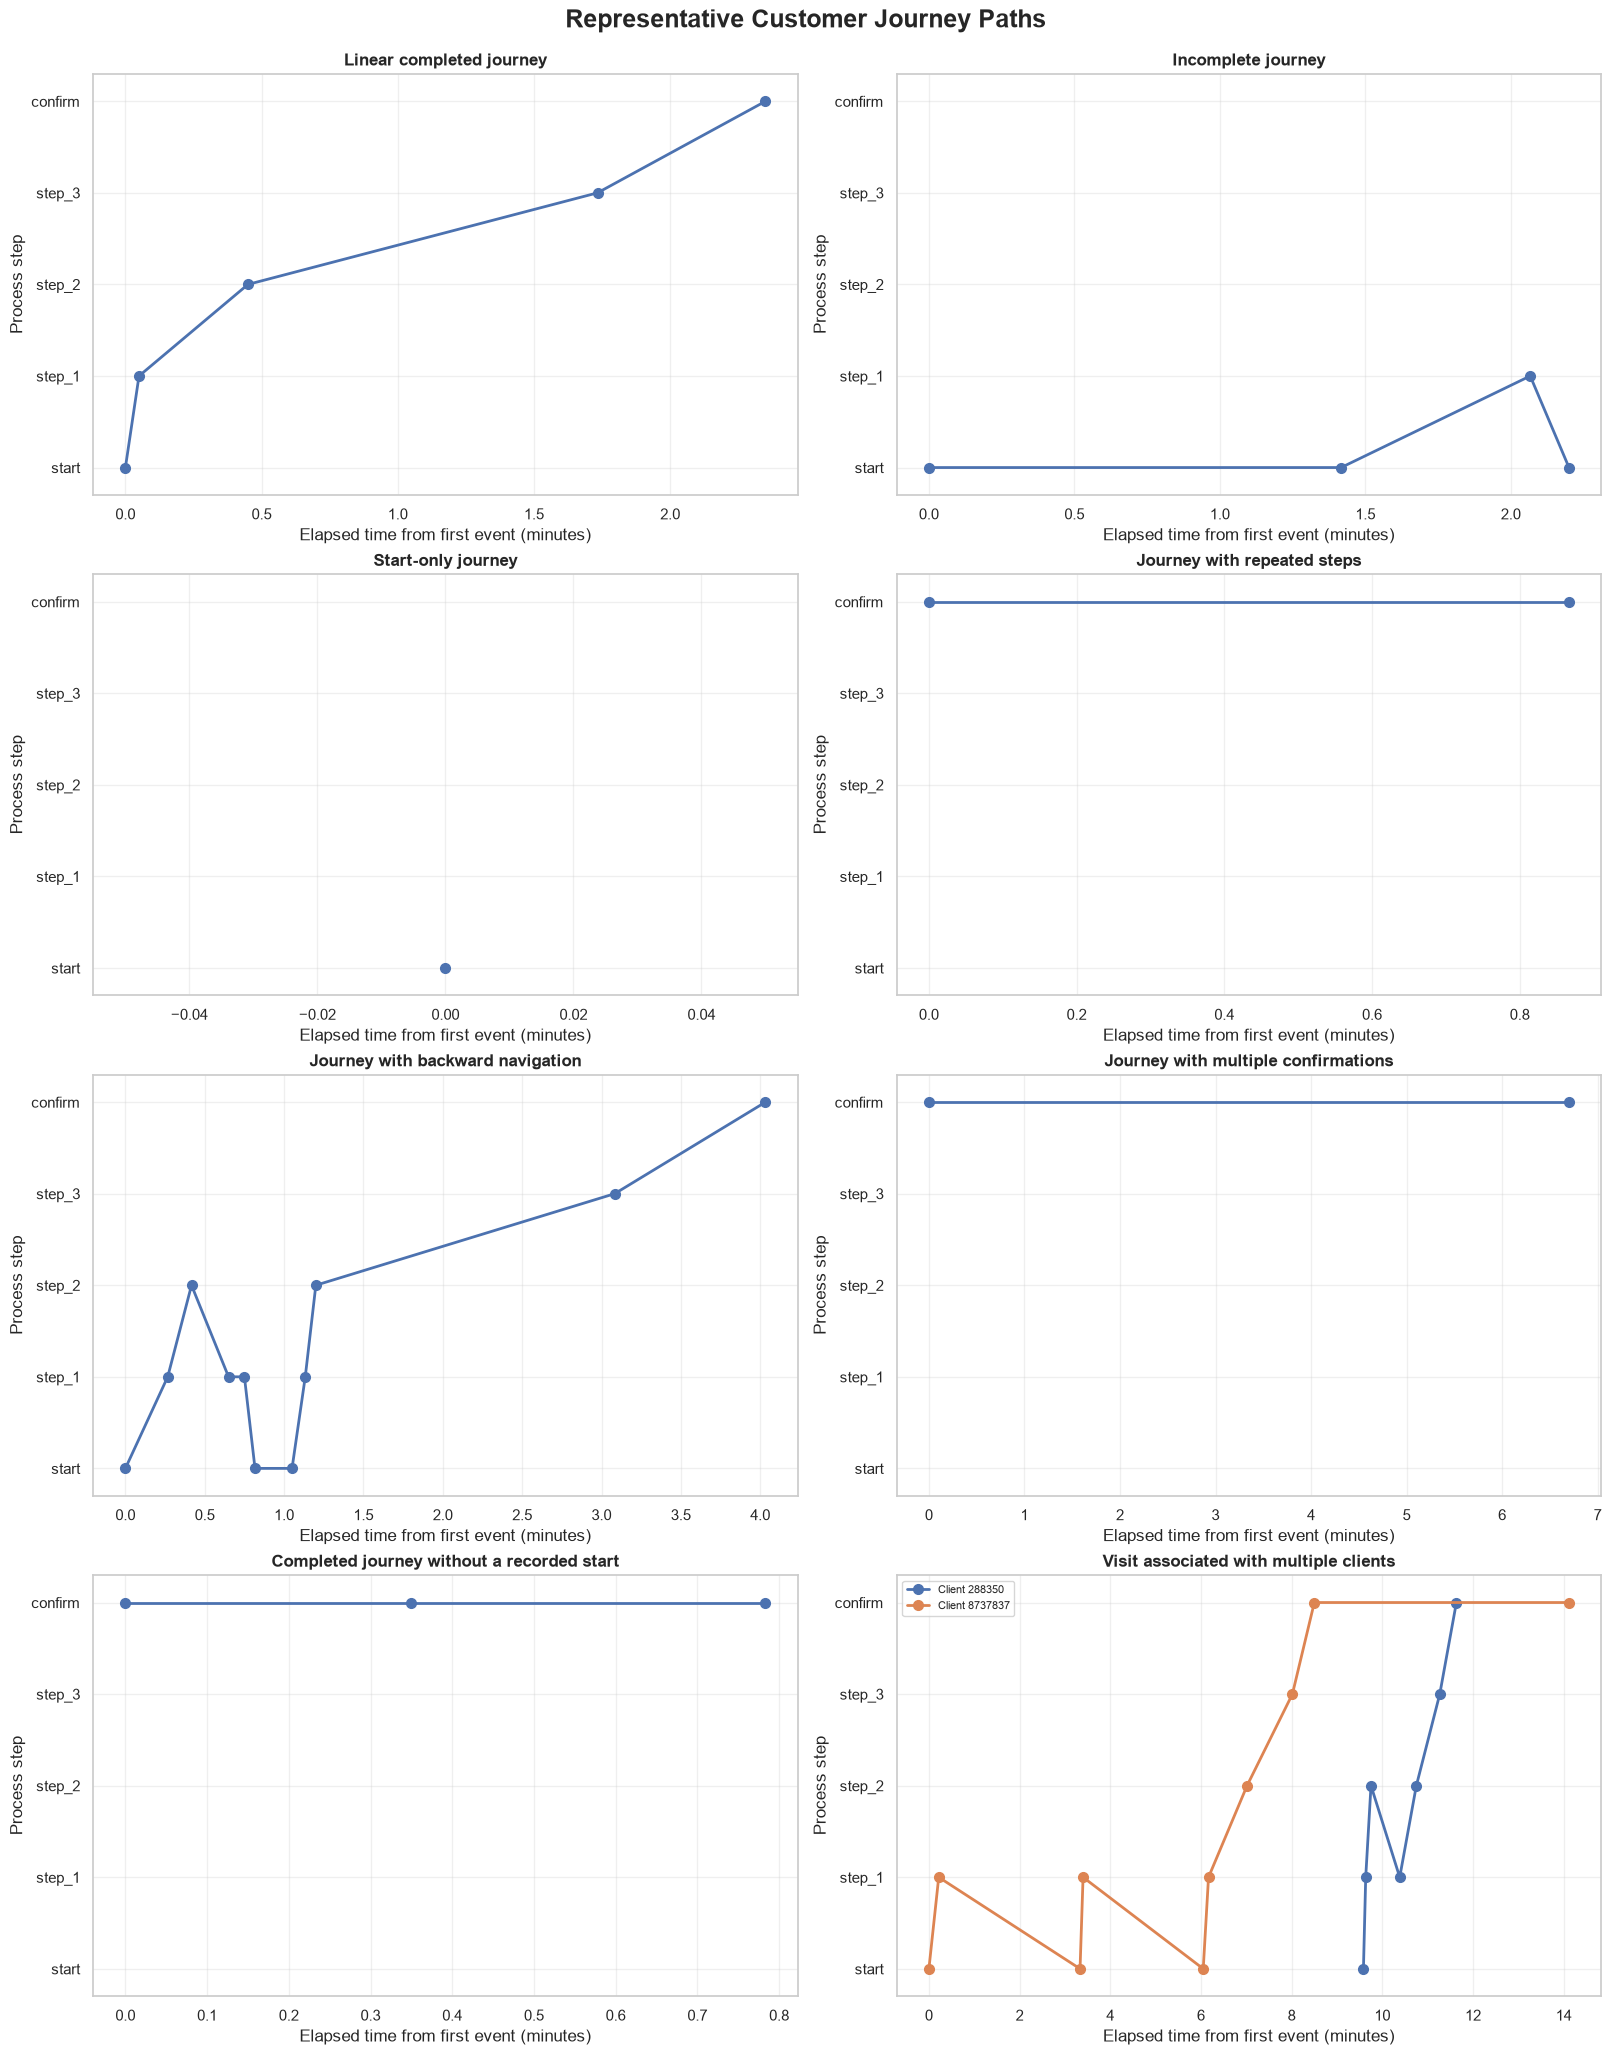

In [14]:
# Calculate elapsed time from the beginning of each visit
web_clean["elapsed_minutes"] = (
    web_clean["date_time"]
    - web_clean.groupby("visit_id")["date_time"].transform("min")
).dt.total_seconds() / 60

# Create one subplot for every representative journey
number_of_plots = len(representative_visits)

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 20),
    constrained_layout=True
)

axes = axes.flatten()

for ax, (_, selected_journey) in zip(
    axes,
    representative_visits.iterrows()
):
    visit_id = selected_journey["visit_id"]
    journey_type = selected_journey["journey_type"]

    visit_events = (
        web_clean[
            web_clean["visit_id"].eq(visit_id)
        ]
        .sort_values("date_time")
        .copy()
    )

    # Draw a separate path for each client in the visit
    for client_id, client_events in visit_events.groupby("client_id"):
        ax.plot(
            client_events["elapsed_minutes"],
            client_events["step_number"],
            marker="o",
            linewidth=2,
            markersize=7,
            label=f"Client {client_id}"
        )

    ax.set_title(journey_type, fontsize=12, fontweight="bold")
    ax.set_xlabel("Elapsed time from first event (minutes)")
    ax.set_ylabel("Process step")

    ax.set_yticks([0, 1, 2, 3, 4])
    ax.set_yticklabels(
        ["start", "step_1", "step_2", "step_3", "confirm"]
    )

    ax.set_ylim(-0.3, 4.3)
    ax.grid(True, alpha=0.3)

    # Show a legend only when multiple clients appear
    if visit_events["client_id"].nunique() > 1:
        ax.legend(fontsize=8)

plt.suptitle(
    "Representative Customer Journey Paths",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.show()

### Interpretation of Representative Journey Charts

The journey-path charts demonstrate that customer behaviour is not always linear.

The linear completed journeys move steadily upward from `start` to `confirm`, showing successful progression through every expected stage. In contrast, incomplete journeys stop before confirmation, while start-only journeys contain no measurable progression beyond the first recorded event.

Horizontal sections of a journey path represent consecutive repeated steps. These may indicate repeated clicks, page refreshes, hesitation or duplicated logging. Downward movements represent customers returning to an earlier stage and may indicate correction, reconsideration or navigation difficulty.

Some journeys contain multiple confirmation events or begin with confirmation without a recorded start. These patterns suggest that the web logs do not always capture a complete attempt within a single visit. Therefore, the presence of a confirmation can establish that completion occurred, but it does not necessarily prove that the entire journey was observed.

The visit associated with multiple clients also demonstrates that `visit_id` cannot always be assumed to represent exactly one client. These visits require special treatment before client-level and journey-level KPIs are calculated.

Overall, the visual inspection confirms that customer journeys must be reconstructed using chronological event order rather than simple event counts.


### Comparing Complete and Incomplete Journeys

Complete and incomplete journeys will now be compared using descriptive statistics and visualisations.

For this exploratory comparison:

* A **complete journey** contains at least one `confirm` event.
* An **incomplete journey** does not contain a `confirm` event.

The comparison examines:

* The number and percentage of journeys in each category
* The typical number of recorded events
* The typical elapsed duration
* Differences in the distributions of journey length and duration

This is an exploratory definition. It will be reviewed when the final analytical methodology is established.


In [15]:
completion_comparison = (
    journey_summary
    .groupby("completed")
    .agg(
        number_of_journeys=("visit_id", "count"),
        mean_events=("number_of_events", "mean"),
        median_events=("number_of_events", "median"),
        mean_duration_minutes=("duration_minutes", "mean"),
        median_duration_minutes=("duration_minutes", "median")
    )
    .reset_index()
)

completion_comparison["completion_status"] = (
    completion_comparison["completed"]
    .map({
        True: "Complete",
        False: "Incomplete"
    })
)

completion_comparison["percentage_of_journeys"] = (
    completion_comparison["number_of_journeys"]
    / completion_comparison["number_of_journeys"].sum()
    * 100
)

completion_comparison[
    [
        "completion_status",
        "number_of_journeys",
        "percentage_of_journeys",
        "mean_events",
        "median_events",
        "mean_duration_minutes",
        "median_duration_minutes"
    ]
].round(2)

,completion_status,number_of_journeys,percentage_of_journeys,mean_events,median_events,mean_duration_minutes,median_duration_minutes
0,Incomplete,68269,43.18,3.56,3.0,3.84,1.02
1,Complete,89826,56.82,5.58,5.0,6.40,3.90


### Visual Comparison of Complete and Incomplete Journeys

The charts below compare the frequency and duration of complete and incomplete journeys.

The first chart displays the percentage of journeys in each completion category. The second chart compares their duration distributions.

Exceptionally long journeys can compress a box plot and make the typical journeys difficult to see. Therefore, the duration box plot is limited to journeys at or below the 99th percentile for visual clarity. This restriction applies only to the chart; the descriptive statistics above were calculated using the complete dataset.


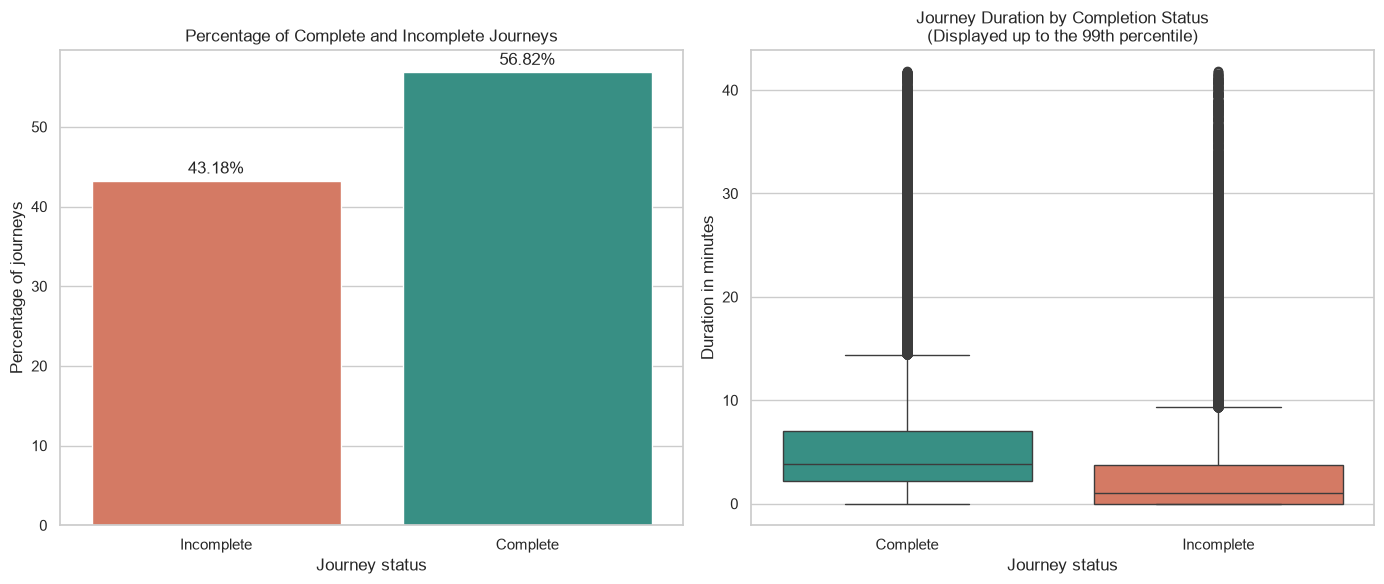

99th percentile of journey duration: 41.8 minutes


In [16]:
# Add readable labels for plotting
journey_plot_data = journey_summary.copy()

journey_plot_data["completion_status"] = np.where(
    journey_plot_data["completed"],
    "Complete",
    "Incomplete"
)

# Calculate the 99th percentile for visualisation only
duration_99th_percentile = (
    journey_plot_data["duration_minutes"].quantile(0.99)
)

duration_plot_data = journey_plot_data[
    journey_plot_data["duration_minutes"]
    <= duration_99th_percentile
].copy()

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 6)
)

# Chart 1: percentage of journeys
sns.barplot(
    data=completion_comparison,
    x="completion_status",
    y="percentage_of_journeys",
    hue="completion_status",
    legend=False,
    palette={
        "Incomplete": "#E76F51",
        "Complete": "#2A9D8F"
    },
    ax=axes[0]
)

axes[0].set_title("Percentage of Complete and Incomplete Journeys")
axes[0].set_xlabel("Journey status")
axes[0].set_ylabel("Percentage of journeys")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

# Chart 2: duration distribution
sns.boxplot(
    data=duration_plot_data,
    x="completion_status",
    y="duration_minutes",
    hue="completion_status",
    legend=False,
    palette={
        "Incomplete": "#E76F51",
        "Complete": "#2A9D8F"
    },
    ax=axes[1]
)

axes[1].set_title(
    "Journey Duration by Completion Status\n"
    "(Displayed up to the 99th percentile)"
)
axes[1].set_xlabel("Journey status")
axes[1].set_ylabel("Duration in minutes")

plt.tight_layout()
plt.show()

print(
    "99th percentile of journey duration:",
    round(duration_99th_percentile, 2),
    "minutes"
)

### Interpretation

Completed journeys represent **56.82%** of all candidate journeys, while incomplete journeys represent **43.18%**.

Completed journeys contain an average of **5.58 events**, compared with **3.56 events** for incomplete journeys. Their median event counts are five and three respectively. This is expected because customers generally need to progress through more stages to reach confirmation.

Completed journeys also have a longer average duration of **6.40 minutes** and a median duration of **3.90 minutes**. Incomplete journeys have a shorter average duration of **3.84 minutes** and a median duration of **1.02 minutes**.

For both categories, the mean duration is higher than the median. This indicates right-skewed distributions: most journeys are relatively short, but a smaller number of longer journeys pull the averages upward.

In the box plot, the line inside each box represents the median duration. The box represents the middle 50% of journeys, between the first and third quartiles. Observations displayed beyond the whiskers are statistical outliers according to the box-plot rule, normally values more than (1.5 \times IQR) below the first quartile or above the third quartile.

The upper outliers show that some customers remained within a recorded visit considerably longer than the typical customer. These observations may represent hesitation, inactivity, interruptions, technical difficulties or customers leaving the website open before returning.

A statistical outlier is not automatically a data error. These journeys may represent genuine customer behaviour and should be investigated before deciding whether they should be removed, capped or analysed separately.

For visual clarity, the chart displays journeys only up to the 99th percentile of duration. Therefore, the most extreme 1% of long journeys are not shown in the box plot, although they remain in the dataset and were included in the descriptive statistics. Their exclusion from the chart prevents a small number of extreme durations from compressing the boxes and hiding the typical distribution.

The longer duration of completed journeys should not automatically be interpreted as poor website performance. Completed customers normally interact with more stages, while many incomplete journeys end shortly after starting. The outliers and the difference in completion status must therefore be considered when defining and comparing completion-time KPIs.



### Full-Dataset Box Plot for Outlier Detection

The earlier box plot was limited to the 99th percentile so that the typical duration distributions could be compared clearly. However, that visualisation did not display the longest 1% of journeys.

The following box plots use the complete journey dataset without removing or capping any observations:

* The first plot uses the original duration scale and shows how extreme values affect the visualisation.
* The second plot uses a logarithmic duration scale, making both typical and extreme journeys easier to inspect.

Points beyond the whiskers represent statistical outliers under the (1.5 \times IQR) box-plot rule. These observations will be investigated rather than automatically removed.


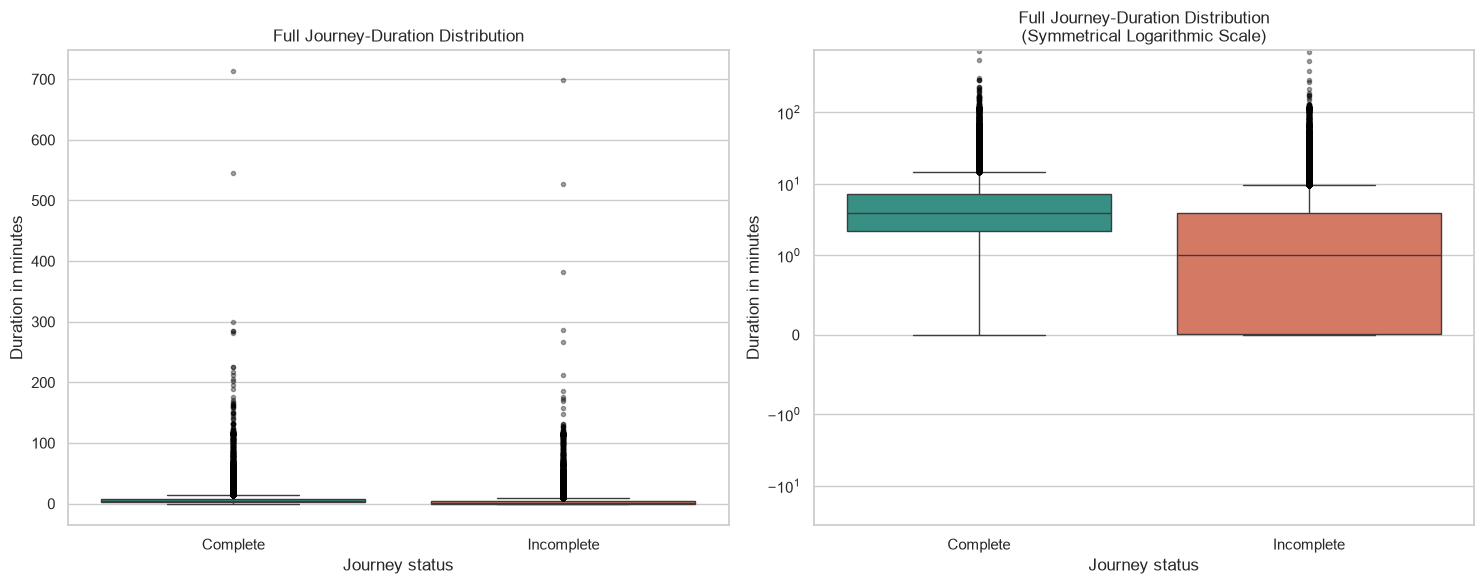

In [19]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

# Full dataset on the original scale
sns.boxplot(
    data=journey_plot_data,
    x="completion_status",
    y="duration_minutes",
    hue="completion_status",
    legend=False,
    palette={
        "Incomplete": "#E76F51",
        "Complete": "#2A9D8F"
    },
    showfliers=True,
    flierprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 3,
        "alpha": 0.35
    },
    ax=axes[0]
)

axes[0].set_title("Full Journey-Duration Distribution")
axes[0].set_xlabel("Journey status")
axes[0].set_ylabel("Duration in minutes")

# Full dataset using a logarithmic scale
sns.boxplot(
    data=journey_plot_data,
    x="completion_status",
    y="duration_minutes",
    hue="completion_status",
    legend=False,
    palette={
        "Incomplete": "#E76F51",
        "Complete": "#2A9D8F"
    },
    showfliers=True,
    flierprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 3,
        "alpha": 0.35
    },
    ax=axes[1]
)

# symlog allows zero-minute journeys while compressing large values
axes[1].set_yscale("symlog", linthresh=1)

axes[1].set_title(
    "Full Journey-Duration Distribution\n"
    "(Symmetrical Logarithmic Scale)"
)
axes[1].set_xlabel("Journey status")
axes[1].set_ylabel("Duration in minutes")

plt.tight_layout()
plt.show()

### Interpretation of Journey-Duration Outliers

The full-data box plots show that journey duration is strongly right-skewed for both complete and incomplete journeys.

On the original scale, the boxes are compressed near the bottom because most journeys are relatively short, while a smaller number last substantially longer. The numerous points above the upper whiskers represent statistical outliers under the (1.5 \times IQR) rule.

Complete journeys have a median duration of approximately **3.90 minutes**, compared with approximately **1.02 minutes** for incomplete journeys. Their middle 50% of values also occurs at a generally higher duration. This is reasonable because completed customers normally need time to progress through more process stages.

Both groups contain many upper-duration outliers. Some complete journeys exceed **700 minutes**, while some incomplete journeys also approach **700 minutes**. These extreme durations are equivalent to several hours and are unlikely to represent continuous active interaction. They may indicate that customers left the website open, paused the process, returned later or experienced an interruption during the visit.

The symmetrical logarithmic box plot makes the typical distributions and outliers more visible at the same time. It confirms that incomplete journeys contain many zero- or near-zero-duration visits. These may represent visits containing only one event or multiple events recorded at the same timestamp. Complete journeys are generally longer, although both groups have long upper tails.

The outliers should not automatically be removed because they may represent genuine customer behaviour rather than data-entry errors. However, using the full elapsed duration without adjustment could overstate the amount of time customers actively spent completing the process.

Therefore, the final methodology should distinguish between:

* **Completion time:** total elapsed time from the first recorded event to confirmation.
* **Effective time:** time associated with active forward progression, excluding or limiting unusually long inactive gaps.

The influence of extreme durations should also be tested through sensitivity analysis—for example, by comparing results using all observations with results using a justified inactivity threshold or capped duration.


### Distribution of Journey Duration

Histograms with Kernel Density Estimate (KDE) curves are used to examine the shape of the journey-duration distributions.

The histogram shows how frequently different journey durations occur, while the KDE curve provides a smoothed representation of the distribution.

Two views are presented:

* The first focuses on durations up to the 99th percentile, making the main distribution readable.
* The second applies a `log(1 + duration)` transformation to the complete dataset, including all outliers and zero-minute journeys.

The logarithmic transformation reduces the visual influence of extreme values without deleting them.


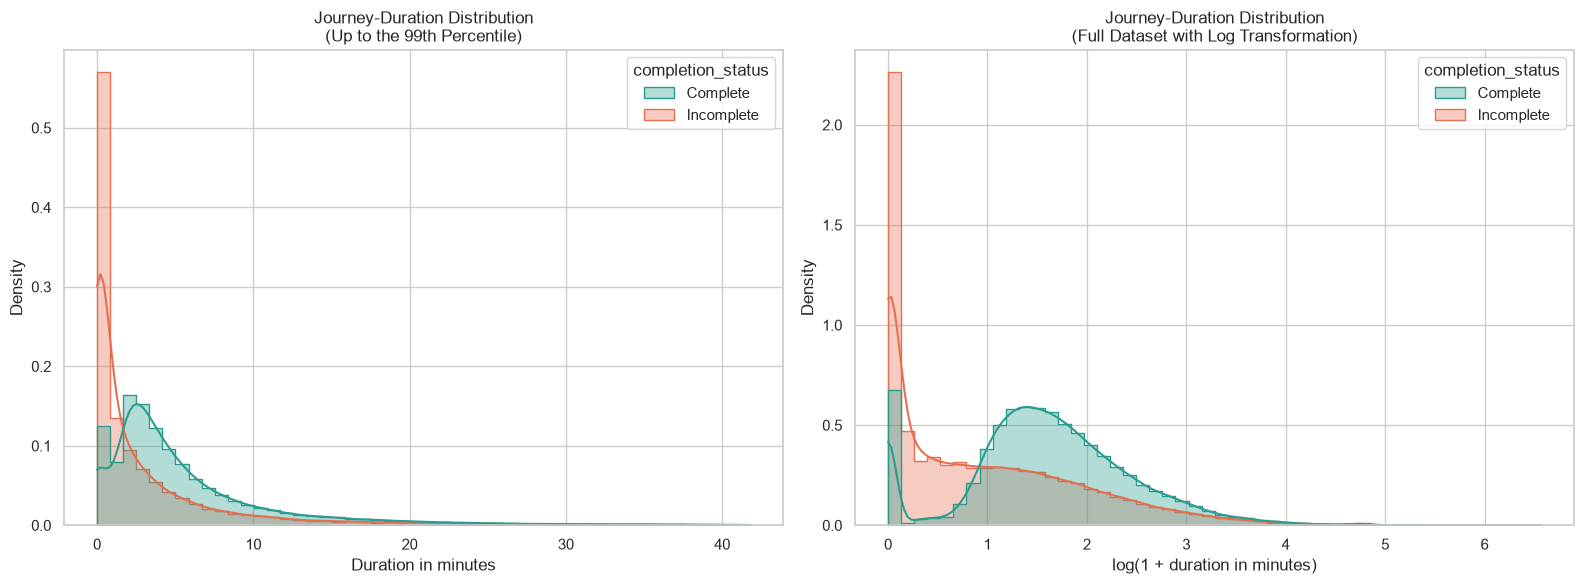

In [20]:
# Create a logarithmically transformed duration for visualisation
journey_plot_data["log_duration"] = np.log1p(
    journey_plot_data["duration_minutes"]
)

# Data up to the 99th percentile for a readable original-scale plot
typical_duration_data = journey_plot_data[
    journey_plot_data["duration_minutes"]
    <= duration_99th_percentile
].copy()

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# Histogram 1: original duration scale up to the 99th percentile
sns.histplot(
    data=typical_duration_data,
    x="duration_minutes",
    hue="completion_status",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.35,
    palette={
        "Incomplete": "#E76F51",
        "Complete": "#2A9D8F"
    },
    ax=axes[0]
)

axes[0].set_title(
    "Journey-Duration Distribution\n"
    "(Up to the 99th Percentile)"
)
axes[0].set_xlabel("Duration in minutes")
axes[0].set_ylabel("Density")

# Histogram 2: transformed full dataset, including all outliers
sns.histplot(
    data=journey_plot_data,
    x="log_duration",
    hue="completion_status",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.35,
    palette={
        "Incomplete": "#E76F51",
        "Complete": "#2A9D8F"
    },
    ax=axes[1]
)

axes[1].set_title(
    "Journey-Duration Distribution\n"
    "(Full Dataset with Log Transformation)"
)
axes[1].set_xlabel("log(1 + duration in minutes)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

### Interpretation of the Duration Histograms

The histogram on the original duration scale shows that most journeys are concentrated at relatively short durations. The distribution then extends gradually toward longer durations, creating a long right-hand tail.

This shape confirms that journey duration is **positively skewed**, or **right-skewed**. The distribution is not symmetrical, and the long-duration observations pull the mean above the median.

Incomplete journeys are more heavily concentrated around zero and very short durations. This is consistent with customers who started but abandoned the process quickly or visits containing only one recorded event.

Completed journeys are generally shifted toward longer durations because customers must progress through more stages before reaching confirmation. However, they also contain a long right-hand tail, showing that some completed journeys took much longer than the typical journey.

The logarithmically transformed histogram includes the complete dataset, including the extreme outliers. The transformation spreads out the large concentration of short journeys and compresses the extremely long durations, making the shapes of both distributions easier to compare.

These findings support using the **median and IQR** alongside the mean and standard deviation when describing journey duration. They also suggest that non-parametric statistical methods may be more appropriate than methods that assume a normal distribution when journey durations are compared later.


### Identifying Common Journey Patterns

After inspecting representative visits, the next step is to determine which exact navigation sequences occur most frequently across the complete dataset.

Each journey sequence will be converted into a readable path. Journeys with the same ordered sequence will then be grouped and counted.

This analysis helps determine:

* Whether the expected linear path is the dominant journey
* Which incomplete paths occur most frequently
* Whether start-only or confirmation-only journeys are common
* How much variation exists in customer navigation
* Which patterns should influence the reconstruction methodology


In [21]:
# Convert each list of steps into a readable journey path
journey_summary["journey_pattern"] = (
    journey_summary["journey_sequence"]
    .apply(lambda steps: " → ".join(steps))
)

# Count every exact journey pattern
pattern_frequency = (
    journey_summary["journey_pattern"]
    .value_counts()
    .rename_axis("journey_pattern")
    .reset_index(name="number_of_journeys")
)

# Calculate the percentage represented by each pattern
pattern_frequency["percentage_of_journeys"] = (
    pattern_frequency["number_of_journeys"]
    / len(journey_summary)
    * 100
)

print(
    "Number of unique exact journey patterns:",
    pattern_frequency.shape[0]
)

top_patterns = pattern_frequency.head(15)

display(
    top_patterns.style.format({
        "number_of_journeys": "{:,.0f}",
        "percentage_of_journeys": "{:.2f}%"
    })
)

Number of unique exact journey patterns: 7273


,journey_pattern,number_of_journeys,percentage_of_journeys
0,start → step_1 → step_2 → step_3 → confirm,"46,129",29.18%
1,start,"16,749",10.59%
2,start → step_1,"8,178",5.17%
3,confirm,"7,982",5.05%
4,start → start,"6,027",3.81%
5,start → step_1 → step_2 → step_3,"4,497",2.84%
6,start → step_1 → start → step_1 → step_2 → step_3 → confirm,"4,034",2.55%
7,start → step_1 → step_2,"3,772",2.39%
8,start → start → step_1 → step_2 → step_3 → confirm,"3,038",1.92%
9,start → step_1 → step_2 → step_3 → confirm → confirm,"2,666",1.69%


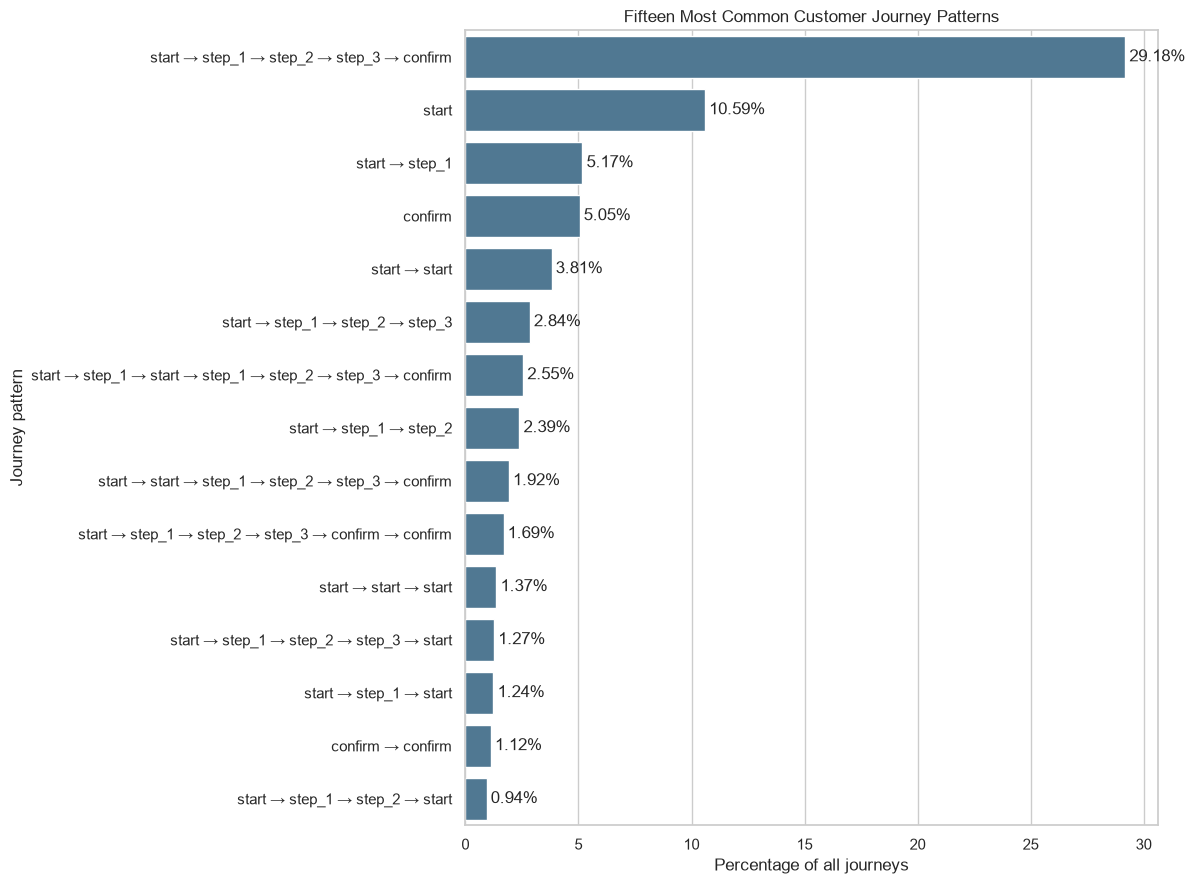

In [22]:
plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=top_patterns,
    x="percentage_of_journeys",
    y="journey_pattern",
    color="#457B9D"
)

plt.title("Fifteen Most Common Customer Journey Patterns")
plt.xlabel("Percentage of all journeys")
plt.ylabel("Journey pattern")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

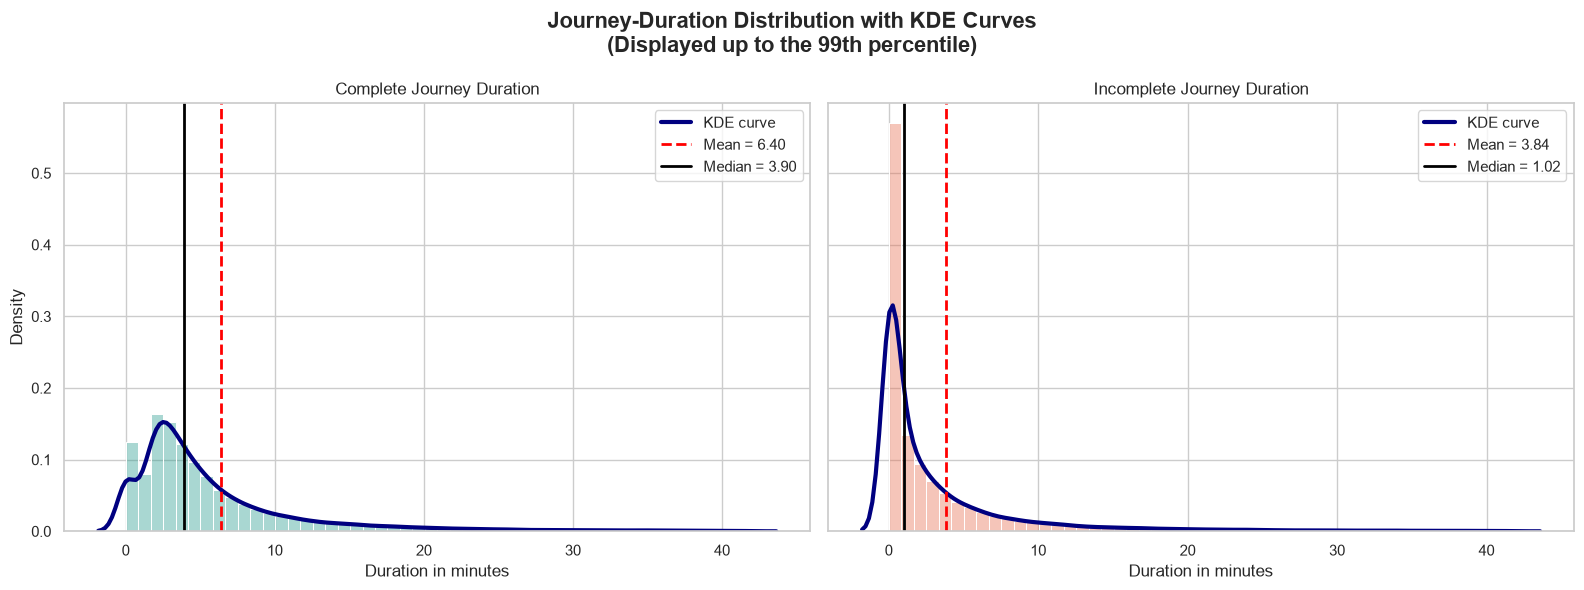

Full-dataset skewness:
completion_status
Complete      12.20
Incomplete    14.41
Name: duration_minutes, dtype: float64


In [25]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharey=True
)

colours = {
    "Complete": "#2A9D8F",
    "Incomplete": "#E76F51"
}

for ax, status in zip(
    axes,
    ["Complete", "Incomplete"]
):
    # Central 99% for readable visualisation
    status_data = histogram_data.loc[
        histogram_data["completion_status"] == status,
        "duration_minutes"
    ]

    # Complete data for mean and median calculations
    full_status_data = journey_plot_data.loc[
        journey_plot_data["completion_status"] == status,
        "duration_minutes"
    ]

    mean_duration = full_status_data.mean()
    median_duration = full_status_data.median()

    # Histogram
    sns.histplot(
        x=status_data,
        bins=50,
        stat="density",
        color=colours[status],
        alpha=0.40,
        edgecolor="white",
        ax=ax
    )

    # Explicit KDE curve
    sns.kdeplot(
        x=status_data,
        color="navy",
        linewidth=3,
        fill=False,
        label="KDE curve",
        ax=ax
    )

    # Mean line
    ax.axvline(
        mean_duration,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_duration:.2f}"
    )

    # Median line
    ax.axvline(
        median_duration,
        color="black",
        linestyle="-",
        linewidth=2,
        label=f"Median = {median_duration:.2f}"
    )

    ax.set_title(f"{status} Journey Duration")
    ax.set_xlabel("Duration in minutes")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle(
    "Journey-Duration Distribution with KDE Curves\n"
    "(Displayed up to the 99th percentile)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print("Full-dataset skewness:")
print(
    journey_plot_data
    .groupby("completion_status")["duration_minutes"]
    .skew()
    .round(2)
)

### Interpretation of Journey-Duration Distribution and Skewness

The histograms and KDE curves compare the duration distributions of complete and incomplete customer journeys.

The bars show the density of observed journey durations, while the dark-blue KDE curves provide smoothed representations of the distributions. The black vertical lines represent the medians, and the red dashed lines represent the means.

For a symmetrical distribution, the KDE curve would have a similar shape on both sides of its centre, and the mean and median would be close together. The displayed distributions are not symmetrical. Both have a large concentration of short-duration journeys and tails extending toward higher durations.

This indicates **positive skewness**, also called **right skewness**.

For complete journeys, the mean duration is approximately **6.40 minutes**, while the median is approximately **3.90 minutes**. For incomplete journeys, the mean is approximately **3.84 minutes**, while the median is approximately **1.02 minutes**. In both groups, the mean is positioned to the right of the median because unusually long journeys pull the mean upward.

Incomplete journeys are concentrated more heavily near zero. This reflects visits in which customers leave shortly after starting, visits containing only one recorded event or multiple events recorded at the same timestamp.

Completed journeys are generally shifted toward longer durations because customers normally need more time to progress through the website process and reach confirmation. However, their long right tail shows that some completed journeys take substantially longer than the typical completed journey.

The histograms display journeys up to the 99th percentile so that the main distribution shapes remain readable. The longest 1% are not displayed in these histograms, but they remain in the dataset, are visible in the full-data box plots and are included in the numerical skewness calculation.

The KDE curves, mean–median differences and positive skewness values provide consistent evidence that journey durations are not normally distributed. Therefore, the **median and IQR** are more representative measures of typical duration than the mean and standard deviation alone. Non-parametric statistical methods may also be more suitable when Control and Test journey durations are compared later.


### Prevalence of Standard and Non-Standard Journey Behaviours

The exact-pattern analysis demonstrates that customers follow many different navigation paths. To support the reconstruction methodology, the main journey behaviours will now be summarised across the complete dataset.

The analysis measures the prevalence of:

* Exact linear completion
* Repeated consecutive steps
* Backward navigation
* Multiple starts
* Multiple confirmations
* Completion without a recorded start
* Start-only journeys
* Visits associated with multiple clients

These categories are not mutually exclusive. For example, a journey may contain repeated steps, backward navigation and multiple starts. Therefore, their percentages should be interpreted independently and should not be added together.


In [26]:
total_journeys = len(journey_summary)

behaviour_counts = {
    "Exact linear completion": (
        journey_summary["linear_complete"].sum()
    ),

    "Repeated consecutive steps": (
        journey_summary["repeated_steps"].gt(0).sum()
    ),

    "Backward navigation": (
        journey_summary["step_backs"].gt(0).sum()
    ),

    "Multiple starts": (
        journey_summary["number_of_starts"].gt(1).sum()
    ),

    "Multiple confirmations": (
        journey_summary["number_of_confirms"].gt(1).sum()
    ),

    "Completed without recorded start": (
        (
            journey_summary["completed"]
            & journey_summary["number_of_starts"].eq(0)
        ).sum()
    ),

    "Start-only journey": (
        journey_summary["journey_sequence"]
        .apply(lambda sequence: sequence == ["start"])
        .sum()
    ),

    "Visit with multiple clients": (
        journey_summary["number_of_clients"].gt(1).sum()
    )
}

behaviour_prevalence = pd.DataFrame({
    "journey_behaviour": behaviour_counts.keys(),
    "number_of_journeys": behaviour_counts.values()
})

behaviour_prevalence["percentage_of_journeys"] = (
    behaviour_prevalence["number_of_journeys"]
    / total_journeys
    * 100
)

behaviour_prevalence = behaviour_prevalence.sort_values(
    "percentage_of_journeys",
    ascending=False
).reset_index(drop=True)

display(
    behaviour_prevalence.style.format({
        "number_of_journeys": "{:,.0f}",
        "percentage_of_journeys": "{:.2f}%"
    })
)

,journey_behaviour,number_of_journeys,percentage_of_journeys
0,Multiple starts,"50,314",31.83%
1,Exact linear completion,"46,129",29.18%
2,Repeated consecutive steps,"44,461",28.12%
3,Backward navigation,"40,469",25.60%
4,Start-only journey,"16,749",10.59%
5,Completed without recorded start,"12,496",7.90%
6,Multiple confirmations,"8,923",5.64%
7,Visit with multiple clients,"1,012",0.64%


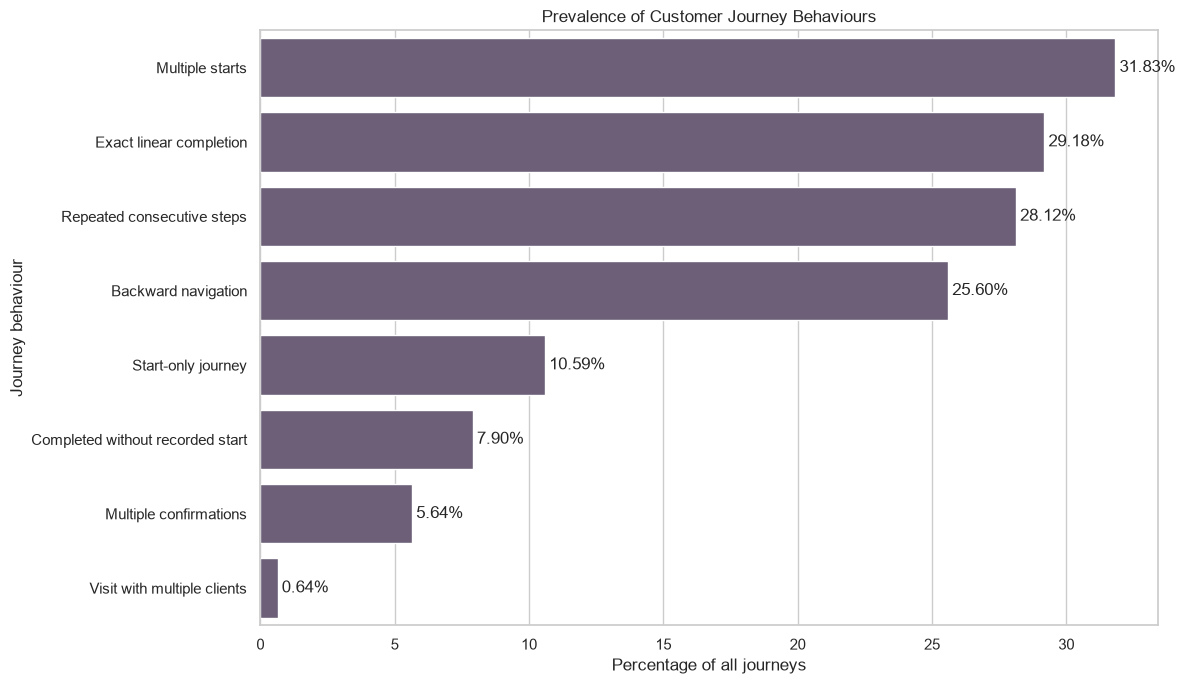

In [27]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=behaviour_prevalence,
    x="percentage_of_journeys",
    y="journey_behaviour",
    color="#6C5B7B"
)

plt.title("Prevalence of Customer Journey Behaviours")
plt.xlabel("Percentage of all journeys")
plt.ylabel("Journey behaviour")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

## 4. Customer-Journey Reconstruction Rules

The exploratory analysis confirms that website visits contain linear completions, incomplete journeys, repeated events, backward navigation, restarts, multiple confirmations and exceptionally long time gaps.

The following rules will be applied consistently when reconstructing customer journeys.

### 1. Primary journey identifier

Each `visit_id` will initially represent one candidate customer journey because it groups events recorded during the same website visit.

However, some `visit_id` values are associated with multiple clients. These visits will be flagged and investigated separately. Events belonging to different clients must not be treated as if they represent one person’s navigation path.

Where necessary, the combination of `client_id` and `visit_id` will be used to separate client-specific journeys within a shared visit.

### 2. Event ordering

Events within each journey will be arranged chronologically using `date_time`.

The original dataframe row order will not be used because the raw files are not reliably stored from the earliest to the latest event.

### 3. Expected process order

The expected forward path is:

> `start` → `step_1` → `step_2` → `step_3` → `confirm`

Each process step is assigned a numerical position from 0 to 4. This allows forward movements, repeated steps and backward movements to be detected consistently.

### 4. Multiple visits by the same client

Each visit will initially be treated as a separate attempt because a client may leave the website and return later.

For journey-level KPIs, every qualifying visit will contribute one observation. For client-level completion, a client will be considered completed if at least one qualifying journey reaches confirmation.

Both journey-level and client-level results will be reported where they answer different business questions:

* Journey level: How successful is an individual website attempt?
* Client level: Did the customer eventually complete the process?

### 5. Incomplete journeys

Journeys without a `confirm` event will be retained because they provide essential information about abandonment and funnel drop-off.

Incomplete journeys will:

* Be included in completion-rate and abandonment-rate denominators.
* Be included in funnel-conversion analysis.
* Not be assigned a completed-journey duration because no confirmation timestamp exists.

### 6. Repeated events

Consecutive occurrences of the same process step will be flagged as repeated events.

Repeated events will be retained for error-rate and navigation-difficulty analysis. However, repeated occurrences of the same stage will not be counted as additional funnel conversions.

### 7. Backward navigation

A movement from a higher-numbered stage to a lower-numbered stage will be classified as a step-back.

Each backward transition will be counted individually for the step-back KPI. The size of the backward movement will also be preserved so that a one-step correction can be distinguished from a complete restart.

### 8. Multiple starts

Repeated `start` events within the same visit will initially remain part of the same candidate journey and will be recorded as restarts.

They will not automatically create multiple completed journeys. Their treatment will be reviewed when active attempts and effective time are calculated.

### 9. Multiple confirmations

A journey containing one or more `confirm` events will count as one completed journey.

Repeated confirmations will not be interpreted as multiple successful completions. The first confirmation will be used as the completion endpoint, while additional confirmations will be retained as repeated-event evidence.

### 10. Confirmation without a recorded start

A journey containing `confirm` but no recorded `start` provides evidence that completion occurred, so it may contribute to the completion-rate calculation.

However, it will not be included in start-to-confirm completion-time calculations because the beginning of the journey was not observed.

### 11. Exceptionally long journeys

Long-duration journeys will not be removed automatically because statistical outliers may represent genuine interruptions or delayed returns rather than data errors.

The distribution of gaps between consecutive events will be examined before choosing an inactivity threshold. Journeys containing unusually long gaps may be:

* Flagged as interrupted.
* Excluded from active-time calculations.
* Included in a sensitivity analysis.
* Reported separately as a methodological limitation.

### 12. Reproducibility

All journey flags and KPI variables will be created using explicit and repeatable code. The original `web_clean` events will remain available so that every aggregated journey result can be traced back to its underlying event records.


## 5. Analysing Time Gaps Between Events

Total journey duration may include periods during which a customer was not actively interacting with the website. For example, a customer may leave the website open, become distracted or return after a long interruption.

To investigate this issue, the time between every pair of consecutive events will be calculated.

Time gaps will be measured within each `client_id` and `visit_id` combination. This prevents events belonging to different clients in a shared visit from being treated as consecutive actions by the same customer.

The gap distribution will be evaluated using:

* Mean and median
* Standard deviation
* Quartiles
* Upper percentiles
* Maximum
* Skewness
* The frequency of zero-minute gaps

This evidence will guide the treatment of interrupted journeys and the definition of effective time.


In [28]:
# Create a client-specific event dataset
journey_events = (
    web_clean
    .sort_values(
        ["client_id", "visit_id", "date_time"],
        kind="mergesort"
    )
    .copy()
)

# Find the preceding timestamp within the same client and visit
journey_events["previous_event_time"] = (
    journey_events
    .groupby(
        ["client_id", "visit_id"]
    )["date_time"]
    .shift(1)
)

# Calculate the gap between consecutive events
journey_events["inter_event_gap_minutes"] = (
    journey_events["date_time"]
    - journey_events["previous_event_time"]
).dt.total_seconds() / 60

# Remove the first event of each journey because it has no preceding event
gap_data = (
    journey_events["inter_event_gap_minutes"]
    .dropna()
)

print("Number of measured inter-event gaps:",
      len(gap_data))

print("Negative time gaps:",
      gap_data.lt(0).sum())

print("Zero-minute time gaps:",
      gap_data.eq(0).sum())

print("\nInter-event gap summary:")
display(
    gap_data.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            0.995,
            0.999
        ]
    ).round(2)
)

print("Skewness:", round(gap_data.skew(), 2))

Number of measured inter-event gaps: 585529
Negative time gaps: 0
Zero-minute time gaps: 953

Inter-event gap summary:


count    585529.00
mean          1.42
std           3.50
min           0.00
25%           0.22
50%           0.58
75%           1.37
90%           3.00
95%           5.15
99%          16.05
99.5%        17.07
99.9%        32.56
max         670.58
Name: inter_event_gap_minutes, dtype: float64

Skewness: 40.06


### Visual Distribution of Inter-Event Time Gaps

The distribution of time gaps between consecutive events is examined using a histogram with a KDE curve and a full-data box plot.

The histogram shows where most time gaps are concentrated and whether the distribution is symmetrical or skewed. Percentile reference lines are included to show where increasingly unusual gaps begin.

The box plot uses the complete dataset and displays statistical outliers according to the (1.5 \times IQR) rule. A symmetrical logarithmic scale is used so that zero-minute gaps, typical gaps and exceptionally long gaps can appear in the same chart.


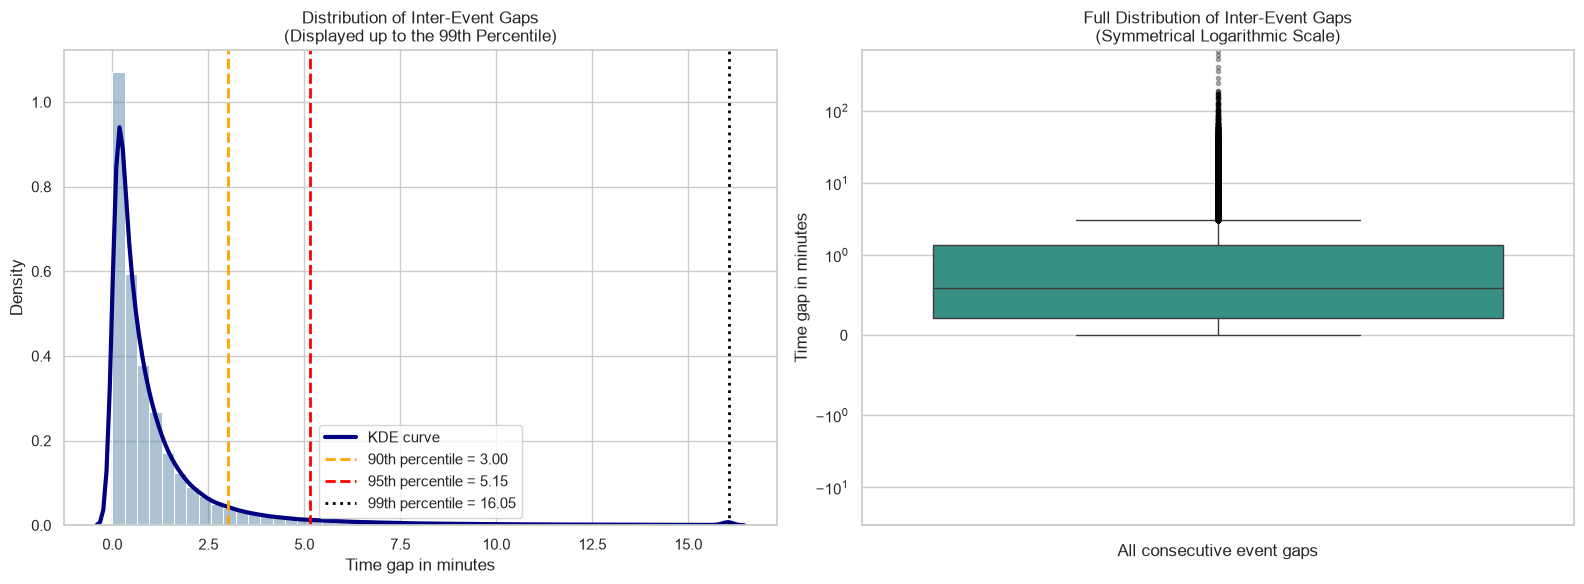

In [30]:
# Calculate percentile reference points
gap_p90 = gap_data.quantile(0.90)
gap_p95 = gap_data.quantile(0.95)
gap_p99 = gap_data.quantile(0.99)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# --------------------------------------------------
# Chart 1: Histogram with explicit KDE curve
# --------------------------------------------------

# Use gaps up to the 99th percentile for readability
gap_histogram_data = gap_data[
    gap_data <= gap_p99
]

sns.histplot(
    x=gap_histogram_data,
    bins=50,
    stat="density",
    color="#457B9D",
    alpha=0.45,
    edgecolor="white",
    ax=axes[0]
)

sns.kdeplot(
    x=gap_histogram_data,
    color="navy",
    linewidth=3,
    label="KDE curve",
    ax=axes[0]
)

# Add percentile reference lines
axes[0].axvline(
    gap_p90,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"90th percentile = {gap_p90:.2f}"
)

axes[0].axvline(
    gap_p95,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"95th percentile = {gap_p95:.2f}"
)

axes[0].axvline(
    gap_p99,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"99th percentile = {gap_p99:.2f}"
)

axes[0].set_title(
    "Distribution of Inter-Event Gaps\n"
    "(Displayed up to the 99th Percentile)"
)
axes[0].set_xlabel("Time gap in minutes")
axes[0].set_ylabel("Density")
axes[0].legend()

# --------------------------------------------------
# Chart 2: Full-data box plot
# --------------------------------------------------

sns.boxplot(
    y=gap_data,
    color="#2A9D8F",
    showfliers=True,
    flierprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 3,
        "alpha": 0.30
    },
    ax=axes[1]
)

axes[1].set_yscale(
    "symlog",
    linthresh=1
)

axes[1].set_title(
    "Full Distribution of Inter-Event Gaps\n"
    "(Symmetrical Logarithmic Scale)"
)
axes[1].set_xlabel("All consecutive event gaps")
axes[1].set_ylabel("Time gap in minutes")

plt.tight_layout()
plt.show()

### Interpretation of Inter-Event Time Gaps

A total of **585,529 time gaps** were measured between consecutive events belonging to the same client and visit. No negative gaps were found, confirming that the events were ordered chronologically.

Only **953 gaps** have a duration of zero minutes. These represent events recorded within the same minute or at exactly the same timestamp and are not automatically considered data errors.

The typical time between consecutive interactions is short. The median gap is **0.58 minutes**, or approximately 35 seconds, while 75% of gaps are no longer than **1.37 minutes**. Furthermore:

* 90% of gaps are no longer than **3.00 minutes**.
* 95% are no longer than **5.15 minutes**.
* 99% are no longer than **16.05 minutes**.
* 99.9% are no longer than **32.56 minutes**.

The mean gap of **1.42 minutes** is considerably higher than the median because a small number of extremely long gaps pull the average upward. The maximum recorded gap is **670.58 minutes**, or more than 11 hours.

The skewness value of **40.06** confirms that the distribution is extremely right-skewed. The histogram and KDE curve should therefore show a large concentration near short durations and a long right-hand tail. The box plot similarly identifies many upper-duration outliers.

Based on this distribution, a **30-minute inactivity threshold** will be used. This threshold is close to the 99.9th percentile, meaning that approximately 99.9% of consecutive interactions occur within this period.

A gap greater than 30 minutes will be classified as an interruption rather than continuous active interaction. This rule is supported by the observed distribution and prevents exceptionally long inactive periods from being treated as time actively spent using the website.


In [31]:
inactivity_threshold_minutes = 30

journey_events["interrupted"] = (
    journey_events["inter_event_gap_minutes"]
    > inactivity_threshold_minutes
)

number_of_interruptions = (
    journey_events["interrupted"].sum()
)

percentage_of_gaps_interrupted = (
    number_of_interruptions
    / gap_data.count()
    * 100
)

# Count client-visit journeys containing at least one interruption
interrupted_journeys = (
    journey_events
    .groupby(
        ["client_id", "visit_id"]
    )["interrupted"]
    .any()
)

number_of_interrupted_journeys = (
    interrupted_journeys.sum()
)

percentage_of_journeys_interrupted = (
    interrupted_journeys.mean()
    * 100
)

print(
    "Inactivity threshold:",
    inactivity_threshold_minutes,
    "minutes"
)

print(
    "Number of gaps exceeding the threshold:",
    number_of_interruptions
)

print(
    "Percentage of measured gaps exceeding the threshold:",
    round(percentage_of_gaps_interrupted, 3),
    "%"
)

print(
    "Number of client-visit journeys with an interruption:",
    number_of_interrupted_journeys
)

print(
    "Percentage of client-visit journeys with an interruption:",
    round(percentage_of_journeys_interrupted, 3),
    "%"
)

Inactivity threshold: 30 minutes
Number of gaps exceeding the threshold: 747
Percentage of measured gaps exceeding the threshold: 0.128 %
Number of client-visit journeys with an interruption: 734
Percentage of client-visit journeys with an interruption: 0.461 %


### Validation of the Inactivity Threshold

Using a 30-minute inactivity threshold identified **747 unusually long gaps**, representing only **0.128%** of all measured inter-event gaps.

These gaps occurred in **734 client-visit journeys**, representing **0.461%** of all client-visit journeys. Therefore, more than 99.5% of journeys contain no interruption longer than 30 minutes.

This result supports the selected threshold because it isolates only the extreme tail of the gap distribution while preserving almost all normal customer interactions.

Interrupted journeys will not be deleted automatically. Instead:

* Their full elapsed duration will remain available for completion-time sensitivity analysis.
* Gaps exceeding 30 minutes will not contribute to effective active time.
* The journeys will receive an interruption flag.
* Their influence on KPI results will be reported as a methodological limitation.

This approach preserves genuine customer behaviour while preventing long inactive periods from being interpreted as continuous website engagement.


## 6. Creating the Analytical Journey Dataset

The exploratory journey summary used `visit_id` as the initial candidate journey identifier. However, some visits are associated with multiple clients.

The final analytical journey unit will therefore use the combination of:

> `client_id` + `visit_id`

This prevents events belonging to different clients within the same visit from being combined into one customer journey.

Navigation movements will also be recalculated within each client-visit journey to ensure that repeated steps and backward movements are attributed to the correct customer.


In [34]:
journey_group = ["client_id", "visit_id"]

# Ensure client-specific chronological ordering
journey_events = (
    journey_events
    .sort_values(
        journey_group + ["date_time"],
        kind="mergesort"
    )
    .reset_index(drop=True)
)

# Recalculate previous steps within each client-visit journey
journey_events["previous_step_number"] = (
    journey_events
    .groupby(journey_group)["step_number"]
    .shift(1)
)

journey_events["step_difference"] = (
    journey_events["step_number"]
    - journey_events["previous_step_number"]
)

journey_events["repeated_step"] = (
    journey_events["step_difference"].eq(0)
)

journey_events["step_back"] = (
    journey_events["step_difference"].lt(0)
)

# Measure how many stages were moved backwards
journey_events["step_back_distance"] = np.where(
    journey_events["step_difference"].lt(0),
    -journey_events["step_difference"],
    0
)

# Count time only when the customer moves forward
# and the gap does not exceed 30 minutes
journey_events["active_forward_minutes"] = np.where(
    journey_events["step_difference"].gt(0)
    & journey_events["inter_event_gap_minutes"].le(
        inactivity_threshold_minutes
    ),
    journey_events["inter_event_gap_minutes"],
    0
)

# Create one row per client-visit journey
client_visit_journeys = (
    journey_events
    .groupby(journey_group)
    .agg(
        visitor_id=("visitor_id", "first"),
        number_of_visitors=("visitor_id", "nunique"),
        journey_start=("date_time", "min"),
        journey_end=("date_time", "max"),
        number_of_events=("process_step", "size"),
        journey_sequence=("process_step", list),
        number_of_starts=(
            "process_step",
            lambda x: x.eq("start").sum()
        ),
        number_of_confirms=(
            "process_step",
            lambda x: x.eq("confirm").sum()
        ),
        repeated_steps=("repeated_step", "sum"),
        step_backs=("step_back", "sum"),
        total_step_back_distance=(
            "step_back_distance",
            "sum"
        ),
        number_of_interruptions=("interrupted", "sum"),
        effective_time_minutes=(
            "active_forward_minutes",
            "sum"
        )
    )
    .reset_index()
)

client_visit_journeys["duration_minutes"] = (
    client_visit_journeys["journey_end"]
    - client_visit_journeys["journey_start"]
).dt.total_seconds() / 60

client_visit_journeys["completed"] = (
    client_visit_journeys["number_of_confirms"] > 0
)

client_visit_journeys["interrupted"] = (
    client_visit_journeys["number_of_interruptions"] > 0
)

print(
    "Final number of client-visit journeys:",
    len(client_visit_journeys)
)

print(
    "Completed client-visit journeys:",
    client_visit_journeys["completed"].sum()
)

print(
    "Interrupted client-visit journeys:",
    client_visit_journeys["interrupted"].sum()
)

client_visit_journeys.head()

Final number of client-visit journeys: 159112
Completed client-visit journeys: 90638
Interrupted client-visit journeys: 734


,client_id,visit_id,visitor_id,number_of_visitors,journey_start,journey_end,number_of_events,journey_sequence,number_of_starts,number_of_confirms,repeated_steps,step_backs,total_step_back_distance,number_of_interruptions,effective_time_minutes,duration_minutes,completed,interrupted
0,169,749567106_99161211863_557568,201385055_71273495308,1,2017-04-12 20:19:36,2017-04-12 20:23:09,5,"[start, step_1, step_2, step_3, confirm]",1,1,0,0,0.0,0,3.550000,3.550000,True,False
1,336,649044751_80905125055_554468,64757908_3400128256,1,2017-06-01 07:26:55,2017-06-01 07:42:43,2,"[start, start]",2,0,1,0,0.0,0,0.000000,15.800000,False,False
2,546,731811517_9330176838_94847,475037402_89828530214,1,2017-06-17 10:03:29,2017-06-17 10:05:42,5,"[start, step_1, step_2, step_3, confirm]",1,1,0,0,0.0,0,2.216667,2.216667,True,False
3,555,637149525_38041617439_716659,402506806_56087378777,1,2017-04-15 12:57:56,2017-04-15 13:00:34,5,"[start, step_1, step_2, step_3, confirm]",1,1,0,0,0.0,0,2.633333,2.633333,True,False
4,647,40369564_40101682850_311847,66758770_53988066587,1,2017-04-12 15:41:28,2017-04-12 15:47:45,5,"[start, step_1, step_2, step_3, confirm]",1,1,0,0,0.0,0,6.283333,6.283333,True,False


### Validation of the Client-Visit Journey Dataset

The final analytical dataset contains **159,112 client-visit journeys**, compared with **158,095 unique `visit_id` values** in the initial exploratory dataset.

The increase occurs because some visits are associated with multiple clients. Using the combination of `client_id` and `visit_id` separates their events and prevents different customers from being represented as one journey.

A total of **90,638 client-visit journeys** contain at least one confirmation event and are provisionally classified as completed.

The dataset also contains **734 interrupted journeys**, meaning that at least one pair of consecutive events within those journeys is separated by more than 30 minutes.

This final client-visit dataset will be used for journey-level KPIs. Client-level summaries will be created separately so that frequent visitors do not automatically receive more weight when the business question concerns individual customers.


## 7. Designing and Computing the Project KPIs

### 7.1 Completion Rate

Completion rate measures the proportion of customers or journeys that successfully reach `confirm`.

A successful completion is defined as the presence of at least one `confirm` event. Repeated confirmations count as only one successful completion.

Two journey-level versions will be calculated:

1. **All-journey completion rate:** includes every observed client-visit journey in the denominator.
2. **Started-journey completion rate:** includes only journeys containing a recorded `start`.

Client-level versions will also be calculated. At the client level, a customer is considered completed if at least one observed journey contains confirmation.

Reporting both analytical levels distinguishes between:

* The probability that an individual website attempt is completed.
* The probability that an observed customer eventually completes the process.


In [35]:
# Create journey-level eligibility flags
client_visit_journeys["has_recorded_start"] = (
    client_visit_journeys["number_of_starts"] > 0
)

client_visit_journeys["started_and_completed"] = (
    client_visit_journeys["has_recorded_start"]
    & client_visit_journeys["completed"]
)

# Create one summary row per client
client_completion_summary = (
    client_visit_journeys
    .groupby("client_id")
    .agg(
        number_of_journeys=("visit_id", "nunique"),
        has_recorded_start=("has_recorded_start", "any"),
        completed=("completed", "any")
    )
    .reset_index()
)

# Calculate the four completion-rate versions
completion_kpis = pd.DataFrame({
    "measurement": [
        "All client-visit journeys",
        "Client-visit journeys with a recorded start",
        "All observed clients",
        "Observed clients with a recorded start"
    ],

    "completed": [
        client_visit_journeys["completed"].sum(),

        client_visit_journeys.loc[
            client_visit_journeys["has_recorded_start"],
            "completed"
        ].sum(),

        client_completion_summary["completed"].sum(),

        client_completion_summary.loc[
            client_completion_summary["has_recorded_start"],
            "completed"
        ].sum()
    ],

    "total_observations": [
        len(client_visit_journeys),

        client_visit_journeys[
            "has_recorded_start"
        ].sum(),

        len(client_completion_summary),

        client_completion_summary[
            "has_recorded_start"
        ].sum()
    ]
})

completion_kpis["completion_rate_percent"] = (
    completion_kpis["completed"]
    / completion_kpis["total_observations"]
    * 100
)

display(
    completion_kpis.style.format({
        "completed": "{:,.0f}",
        "total_observations": "{:,.0f}",
        "completion_rate_percent": "{:.2f}%"
    })
)

,measurement,completed,total_observations,completion_rate_percent
0,All client-visit journeys,"90,638","159,112",56.96%
1,Client-visit journeys with a recorded start,"78,065","145,835",53.53%
2,All observed clients,"81,145","120,157",67.53%
3,Observed clients with a recorded start,"80,085","118,980",67.31%


### Interpretation and Selected Completion-Rate Methodology

The all-journey completion rate is **56.96%**, meaning that 90,638 of the 159,112 observed client-visit journeys contain at least one confirmation.

When the denominator is restricted to journeys with a recorded `start`, the completion rate is **53.53%**. This rate is lower because confirmation-only journeys are excluded from both the completed count and the denominator.

At the client level, **67.53%** of all observed clients completed the process at least once. When only clients with a recorded start are included, the rate is **67.31%**.

The higher client-level rates indicate that some customers make multiple attempts. A client may have an incomplete journey followed by a successful journey and is therefore unsuccessful in one journey-level observation but successful in the final client-level outcome.

The difference between the two client-level rates is only **0.22 percentage points**. This suggests that restricting the denominator to clients with a recorded start has little effect on the overall customer-level result.

For the final A/B test, the **primary completion-rate KPI will be measured at the client level** because the business question concerns whether customers successfully complete the process. Every client assigned to the Control or Test group will be included once, and a client will be classified as completed if any of their recorded events contains `confirm`.

Clients assigned to an experimental group but without a confirmation will be treated as not completed, including clients with no matched web events. This follows an intention-to-treat approach and preserves the original experimental groups.

Journey-level completion will remain a secondary diagnostic KPI because it measures the success of individual website attempts and reveals the effect of repeated visits.


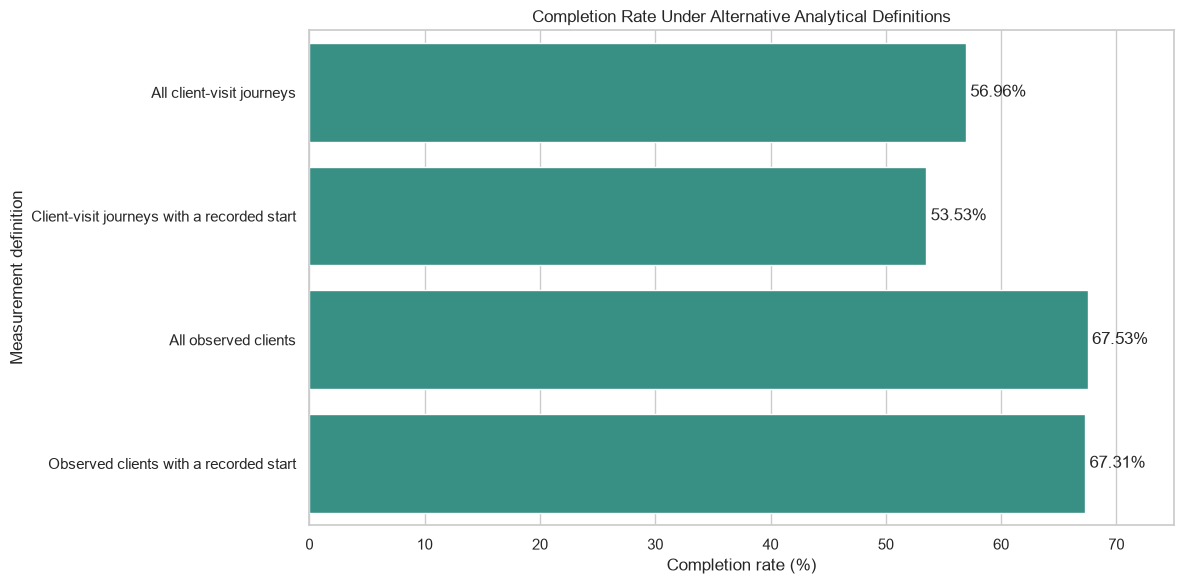

In [36]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=completion_kpis,
    x="completion_rate_percent",
    y="measurement",
    color="#2A9D8F"
)

plt.title("Completion Rate Under Alternative Analytical Definitions")
plt.xlabel("Completion rate (%)")
plt.ylabel("Measurement definition")
plt.xlim(0, 75)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### 7.2 Funnel Conversion

Funnel conversion measures how successfully customers progress from one stage of the website process to the next.

The expected sequence is:

> `start` → `step_1` → `step_2` → `step_3` → `confirm`

A stage will count as reached only when it occurs after the preceding required stage. This prevents unordered events from being incorrectly treated as successful progression.

Methodological rules:

* Each stage is counted only once per client-visit journey.
* Repeated events do not create additional conversions.
* Backward movements do not remove a stage that was already reached.
* A later return to forward progression can continue the funnel.
* Journeys without a recorded `start` are excluded from the ordered funnel.
* Confirmation-only journeys may count toward completion rate but not toward full-funnel conversion.
* Incomplete journeys remain in the funnel and contribute to drop-off.


In [38]:
# Ensure the journey grouping and required flags exist
journey_group = ["client_id", "visit_id"]

journey_events["is_start"] = (
    journey_events["process_step"].eq("start")
)

journey_events["is_confirm"] = (
    journey_events["process_step"].eq("confirm")
)

In [39]:
# Did the journey reach a recorded start by this event?
journey_events["reached_start_so_far"] = (
    journey_events
    .groupby(journey_group)["is_start"]
    .cummax()
)

# Step 1 must occur after a recorded start
journey_events["valid_step_1_event"] = (
    journey_events["process_step"].eq("step_1")
    & journey_events["reached_start_so_far"]
)

journey_events["reached_step_1_so_far"] = (
    journey_events
    .groupby(journey_group)["valid_step_1_event"]
    .cummax()
)

# Step 2 must occur after Step 1
journey_events["valid_step_2_event"] = (
    journey_events["process_step"].eq("step_2")
    & journey_events["reached_step_1_so_far"]
)

journey_events["reached_step_2_so_far"] = (
    journey_events
    .groupby(journey_group)["valid_step_2_event"]
    .cummax()
)

# Step 3 must occur after Step 2
journey_events["valid_step_3_event"] = (
    journey_events["process_step"].eq("step_3")
    & journey_events["reached_step_2_so_far"]
)

journey_events["reached_step_3_so_far"] = (
    journey_events
    .groupby(journey_group)["valid_step_3_event"]
    .cummax()
)

# Confirm must occur after Step 3
journey_events["valid_confirm_event"] = (
    journey_events["process_step"].eq("confirm")
    & journey_events["reached_step_3_so_far"]
)

# Create one ordered-funnel summary per client-visit journey
journey_funnel = (
    journey_events
    .groupby(journey_group)
    .agg(
        reached_start=("is_start", "any"),
        reached_step_1=("valid_step_1_event", "any"),
        reached_step_2=("valid_step_2_event", "any"),
        reached_step_3=("valid_step_3_event", "any"),
        reached_confirm=("valid_confirm_event", "any")
    )
    .reset_index()
)

stage_columns = [
    "reached_start",
    "reached_step_1",
    "reached_step_2",
    "reached_step_3",
    "reached_confirm"
]

stage_names = [
    "Start",
    "Step 1",
    "Step 2",
    "Step 3",
    "Confirm"
]

stage_counts = [
    journey_funnel[column].sum()
    for column in stage_columns
]

funnel_summary = pd.DataFrame({
    "stage": stage_names,
    "journeys_reaching_stage": stage_counts
})

# Percentage relative to journeys that reached Start
start_count = stage_counts[0]

funnel_summary["percentage_of_started_journeys"] = (
    funnel_summary["journeys_reaching_stage"]
    / start_count
    * 100
)

# Conversion from the immediately preceding stage
funnel_summary["conversion_from_previous_stage"] = [
    100
] + [
    stage_counts[index] / stage_counts[index - 1] * 100
    for index in range(1, len(stage_counts))
]

# Drop-off from the previous stage
funnel_summary["drop_off_from_previous_stage"] = (
    100
    - funnel_summary["conversion_from_previous_stage"]
)

display(
    funnel_summary.style.format({
        "journeys_reaching_stage": "{:,.0f}",
        "percentage_of_started_journeys": "{:.2f}%",
        "conversion_from_previous_stage": "{:.2f}%",
        "drop_off_from_previous_stage": "{:.2f}%"
    })
)

,stage,journeys_reaching_stage,percentage_of_started_journeys,conversion_from_previous_stage,drop_off_from_previous_stage
0,Start,"145,835",100.00%,100.00%,0.00%
1,Step 1,"118,552",81.29%,81.29%,18.71%
2,Step 2,"103,053",70.66%,86.93%,13.07%
3,Step 3,"92,757",63.60%,90.01%,9.99%
4,Confirm,"77,710",53.29%,83.78%,16.22%


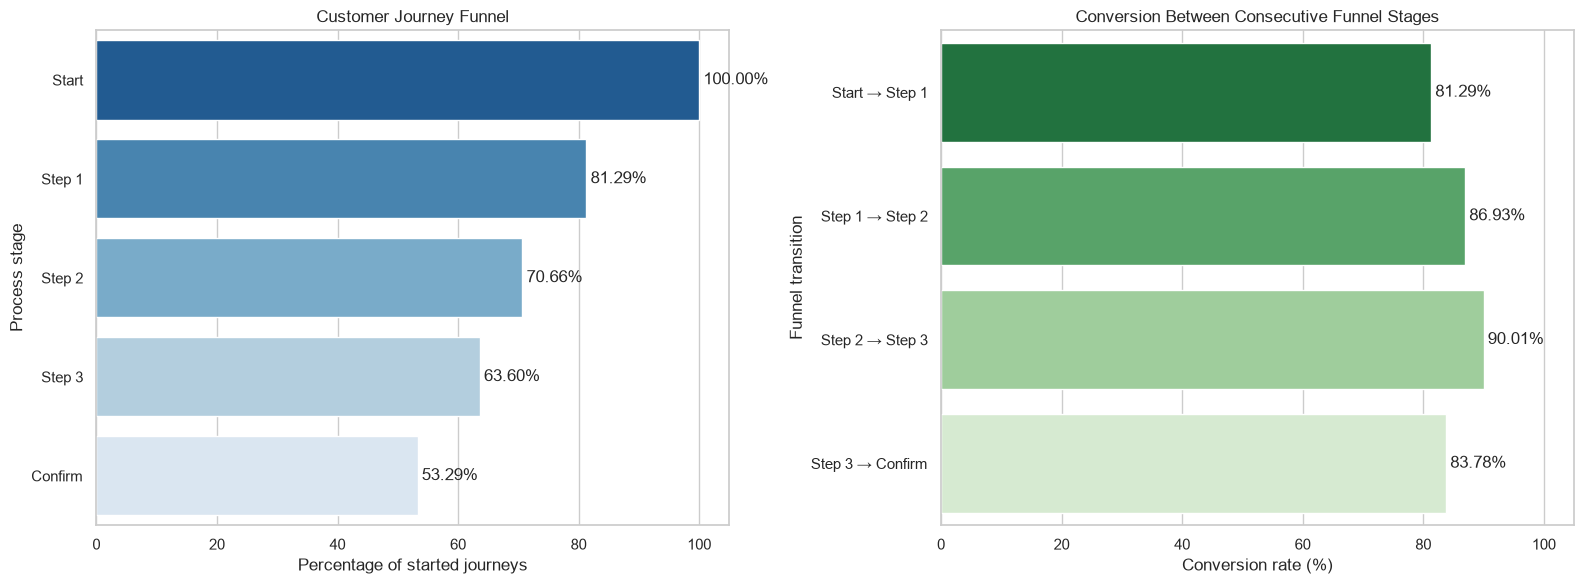

In [40]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# Chart 1: percentage of started journeys reaching each stage
sns.barplot(
    data=funnel_summary,
    x="percentage_of_started_journeys",
    y="stage",
    hue="stage",
    legend=False,
    palette="Blues_r",
    ax=axes[0]
)

axes[0].set_title("Customer Journey Funnel")
axes[0].set_xlabel("Percentage of started journeys")
axes[0].set_ylabel("Process stage")
axes[0].set_xlim(0, 105)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

# Chart 2: conversion from each preceding stage
transition_data = funnel_summary.iloc[1:].copy()

transition_data["transition"] = [
    "Start → Step 1",
    "Step 1 → Step 2",
    "Step 2 → Step 3",
    "Step 3 → Confirm"
]

sns.barplot(
    data=transition_data,
    x="conversion_from_previous_stage",
    y="transition",
    hue="transition",
    legend=False,
    palette="Greens_r",
    ax=axes[1]
)

axes[1].set_title("Conversion Between Consecutive Funnel Stages")
axes[1].set_xlabel("Conversion rate (%)")
axes[1].set_ylabel("Funnel transition")
axes[1].set_xlim(0, 105)

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Funnel Conversion Results

A total of **145,835 client-visit journeys** contain a recorded `start` and form the denominator of the ordered funnel.

Of these started journeys:

* **81.29%** progressed from `start` to `step_1`.
* **70.66%** reached `step_2`.
* **63.60%** reached `step_3`.
* **53.29%** reached `confirm` through the complete ordered funnel.

The largest stage-to-stage drop-off occurs between `start` and `step_1`. Only **81.29%** of started journeys reached the first step, producing a drop-off of **18.71%**. This suggests that the beginning of the process is an important area for further investigation.

Conversion improves during the middle of the funnel:

* `step_1 → step_2`: **86.93%** conversion and **13.07%** drop-off.
* `step_2 → step_3`: **90.01%** conversion and **9.99%** drop-off.

The `step_2 → step_3` transition has the highest conversion rate, suggesting that customers who reach Step 2 are relatively likely to continue to Step 3.

The final `step_3 → confirm` transition has an **83.78%** conversion rate and a **16.22%** drop-off. This is the second-largest drop-off and may indicate hesitation, technical difficulty or abandonment immediately before confirmation.

The ordered-funnel completion count is **77,710**, while **78,065** started journeys contain a confirmation under the broader completion definition. The difference represents journeys that contain both a start and confirmation but do not contain every intermediate stage in the required chronological order.

This distinction demonstrates why completion rate and ordered-funnel conversion should be reported separately:

* Completion rate asks whether confirmation occurred.
* Funnel conversion asks whether the expected sequence was successfully observed.


### 7.3 Completion Time

Completion time measures the elapsed time required to complete a successful website attempt.

The following methodology will be used:

* A valid completion must contain a recorded `start` followed later by `confirm`.
* The first confirmation occurring after a recorded start will be used as the completion endpoint.
* If several starts occur before confirmation, the last start before the first valid confirmation will represent the beginning of the successful attempt.
* Repeated confirmation events will not extend completion time.
* Confirmation-only journeys will not receive a completion time because their starting point was not observed.
* Incomplete journeys will not receive a completion time because no valid confirmation endpoint exists.
* Long inactive periods remain included in total completion time but are treated separately in effective time.

This definition measures the elapsed duration of the final observed attempt that successfully reached confirmation.


In [41]:
# A valid confirmation must occur after a recorded start
journey_events["valid_confirm_after_start"] = (
    journey_events["is_confirm"]
    & journey_events["reached_start_so_far"]
)

grouping_keys = [
    journey_events["client_id"],
    journey_events["visit_id"]
]

# Find the first confirmation occurring after a start
journey_events["first_valid_confirm_time"] = (
    journey_events["date_time"]
    .where(journey_events["valid_confirm_after_start"])
    .groupby(grouping_keys)
    .transform("min")
)

# Identify starts occurring before the selected confirmation
journey_events["eligible_start"] = (
    journey_events["is_start"]
    & journey_events["first_valid_confirm_time"].notna()
    & (
        journey_events["date_time"]
        <= journey_events["first_valid_confirm_time"]
    )
)

# Find the final start before the first valid confirmation
journey_events["last_start_before_confirm"] = (
    journey_events["date_time"]
    .where(journey_events["eligible_start"])
    .groupby(grouping_keys)
    .transform("max")
)

# Calculate total completion time
journey_events["completion_time_minutes"] = (
    journey_events["first_valid_confirm_time"]
    - journey_events["last_start_before_confirm"]
).dt.total_seconds() / 60

# Identify events within the successful attempt
journey_events["within_successful_attempt"] = (
    journey_events["last_start_before_confirm"].notna()
    & (
        journey_events["date_time"]
        >= journey_events["last_start_before_confirm"]
    )
    & (
        journey_events["date_time"]
        <= journey_events["first_valid_confirm_time"]
    )
)

# Effective time counts only active forward movements
# within the successful attempt
journey_events["successful_active_minutes"] = np.where(
    journey_events["within_successful_attempt"]
    & journey_events["step_difference"].gt(0)
    & journey_events["inter_event_gap_minutes"].le(
        inactivity_threshold_minutes
    ),
    journey_events["inter_event_gap_minutes"],
    0
)

# Flag interruptions occurring within successful attempts
journey_events["attempt_interruption"] = (
    journey_events["within_successful_attempt"]
    & journey_events["interrupted"]
)

# Create one completion-time record per client-visit journey
completion_time_summary = (
    journey_events
    .groupby(journey_group)
    .agg(
        first_valid_confirm_time=(
            "first_valid_confirm_time",
            "first"
        ),
        last_start_before_confirm=(
            "last_start_before_confirm",
            "first"
        ),
        completion_time_minutes=(
            "completion_time_minutes",
            "first"
        ),
        effective_time_minutes=(
            "successful_active_minutes",
            "sum"
        ),
        interrupted_during_attempt=(
            "attempt_interruption",
            "any"
        )
    )
    .reset_index()
)

valid_completion_times = (
    completion_time_summary[
        "completion_time_minutes"
    ].dropna()
)

print(
    "Journeys with a valid completion time:",
    valid_completion_times.count()
)

print(
    "Journeys without a valid completion time:",
    completion_time_summary[
        "completion_time_minutes"
    ].isna().sum()
)

print("\nCompletion-time descriptive statistics:")

display(
    valid_completion_times.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    ).round(2)
)

print(
    "Completion-time skewness:",
    round(valid_completion_times.skew(), 2)
)

Journeys with a valid completion time: 78005
Journeys without a valid completion time: 81107

Completion-time descriptive statistics:


count    78005.00
mean         4.94
std          4.80
min          0.08
25%          2.30
50%          3.48
75%          5.73
90%          9.65
95%         13.38
99%         24.17
max        105.58
Name: completion_time_minutes, dtype: float64

Completion-time skewness: 4.56


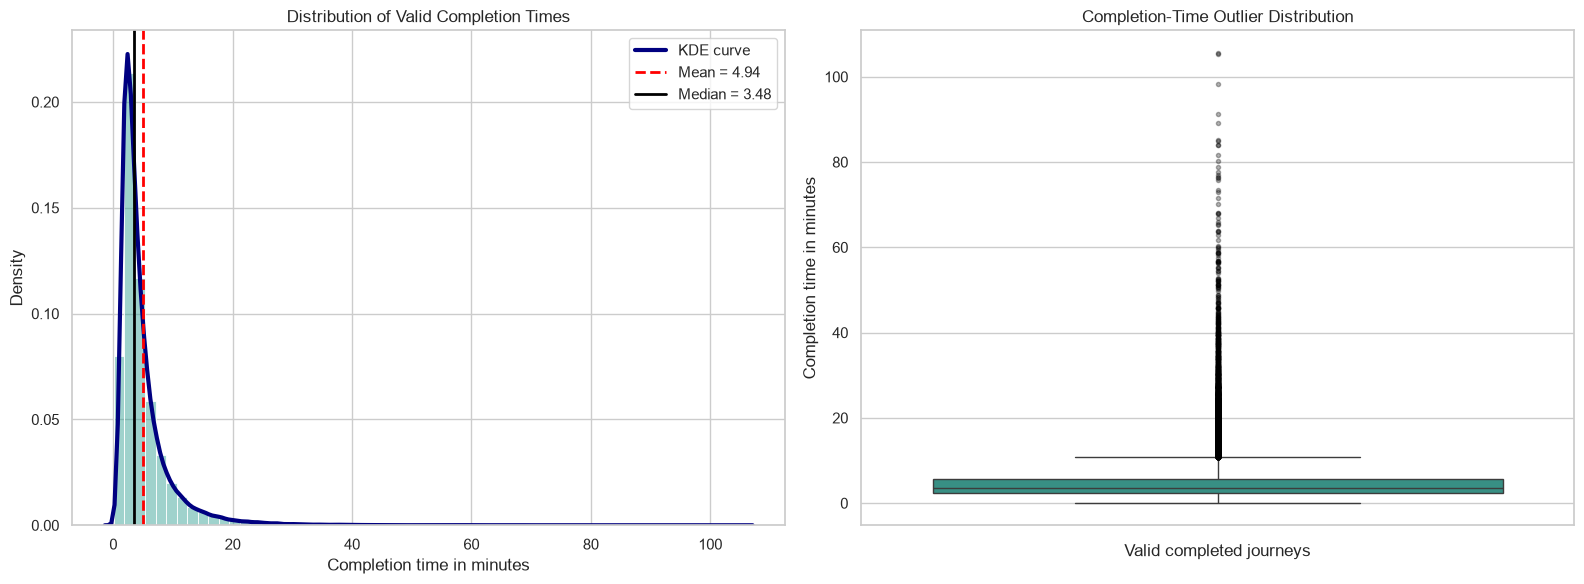

Completion-time skewness: 4.56


In [42]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

completion_mean = valid_completion_times.mean()
completion_median = valid_completion_times.median()

# Histogram with explicit KDE
sns.histplot(
    x=valid_completion_times,
    bins=60,
    stat="density",
    color="#2A9D8F",
    alpha=0.45,
    edgecolor="white",
    ax=axes[0]
)

sns.kdeplot(
    x=valid_completion_times,
    color="navy",
    linewidth=3,
    label="KDE curve",
    ax=axes[0]
)

axes[0].axvline(
    completion_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {completion_mean:.2f}"
)

axes[0].axvline(
    completion_median,
    color="black",
    linestyle="-",
    linewidth=2,
    label=f"Median = {completion_median:.2f}"
)

axes[0].set_title("Distribution of Valid Completion Times")
axes[0].set_xlabel("Completion time in minutes")
axes[0].set_ylabel("Density")
axes[0].legend()

# Full-data box plot
sns.boxplot(
    y=valid_completion_times,
    color="#2A9D8F",
    showfliers=True,
    flierprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 3,
        "alpha": 0.30
    },
    ax=axes[1]
)

axes[1].set_title("Completion-Time Outlier Distribution")
axes[1].set_xlabel("Valid completed journeys")
axes[1].set_ylabel("Completion time in minutes")

plt.tight_layout()
plt.show()

print(
    "Completion-time skewness:",
    round(valid_completion_times.skew(), 2)
)

### Completion-Time Results and Validation

A total of **78,005 client-visit journeys** have a valid completion time. These journeys contain a recorded start followed chronologically by confirmation.

The median completion time is **3.48 minutes**, meaning that half of valid completed journeys finish within approximately three and a half minutes. The middle 50% of journeys take between **2.30 and 5.73 minutes**.

The mean completion time is **4.94 minutes**, which is higher than the median. The histogram and KDE curve show that the distribution is positively skewed, with most journeys concentrated at shorter durations and a long tail extending toward higher values.

The upper percentiles show that:

* 90% of valid completions finish within **9.65 minutes**.
* 95% finish within **13.38 minutes**.
* 99% finish within **24.17 minutes**.

The maximum valid completion time is **105.58 minutes**. The box plot identifies the longest completion times as statistical outliers. These outliers may represent hesitation, corrections, technical difficulties or interruptions during an otherwise successful attempt.

There are **60 journeys** containing both a recorded start and confirmation that do not receive a valid completion time because confirmation occurs before the recorded start. This reinforces the importance of chronological validation rather than assuming that the mere presence of both events establishes a measurable start-to-confirm duration.

Because the completion-time distribution is right-skewed and contains upper outliers, the **median and IQR** should be reported as the primary descriptive measures. The mean can be reported as a supplementary measure but is more sensitive to unusually long journeys.


### 7.4 Effective Time

Effective time estimates how much of a completed journey was associated with active forward progression through the process.

For each valid successful attempt, effective time is calculated as the sum of inter-event gaps where:

* The customer moves to a higher-numbered process stage.
* The movement occurs between the selected start and first valid confirmation.
* The gap does not exceed the 30-minute inactivity threshold.

Time associated with the following behaviours is excluded:

* Repeated steps
* Backward navigation
* Restarts
* Gaps exceeding 30 minutes
* Events occurring before the selected successful start
* Events occurring after the first valid confirmation

Effective time is an analytical proxy for active progression. It does not prove that the customer was continuously attentive during every included interval.


In [43]:
# Keep journeys with a valid completion time
completed_time_kpis = (
    completion_time_summary[
        completion_time_summary[
            "completion_time_minutes"
        ].notna()
    ]
    .copy()
)

# Calculate time not associated with active forward progression
completed_time_kpis["non_progression_minutes"] = (
    completed_time_kpis["completion_time_minutes"]
    - completed_time_kpis["effective_time_minutes"]
)

# Percentage of completion time associated with forward progression
completed_time_kpis["effective_time_percentage"] = (
    completed_time_kpis["effective_time_minutes"]
    / completed_time_kpis["completion_time_minutes"]
    * 100
)

# Validation checks
print(
    "Valid completed journeys:",
    len(completed_time_kpis)
)

print(
    "Negative effective times:",
    completed_time_kpis[
        "effective_time_minutes"
    ].lt(0).sum()
)

print(
    "Effective time greater than completion time:",
    (
        completed_time_kpis["effective_time_minutes"]
        > completed_time_kpis["completion_time_minutes"]
    ).sum()
)

print(
    "Zero effective times:",
    completed_time_kpis[
        "effective_time_minutes"
    ].eq(0).sum()
)

print(
    "Completed attempts containing an interruption:",
    completed_time_kpis[
        "interrupted_during_attempt"
    ].sum()
)

# Descriptive comparison
time_kpi_summary = (
    completed_time_kpis[
        [
            "completion_time_minutes",
            "effective_time_minutes",
            "non_progression_minutes",
            "effective_time_percentage"
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

display(time_kpi_summary.round(2))

Valid completed journeys: 78005
Negative effective times: 0
Effective time greater than completion time: 8419
Zero effective times: 0
Completed attempts containing an interruption: 261


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
completion_time_minutes,78005.0,4.94,4.80,0.08,2.30,3.48,5.73,9.65,13.38,24.17,105.58
effective_time_minutes,78005.0,4.54,3.79,0.08,2.23,3.33,5.38,8.80,12.00,20.03,55.20
non_progression_minutes,78005.0,0.40,2.50,-0.00,0.00,0.00,0.00,0.47,1.72,9.00,101.63
effective_time_percentage,78005.0,96.37,12.20,1.67,100.00,100.00,100.00,100.00,100.00,100.00,100.00


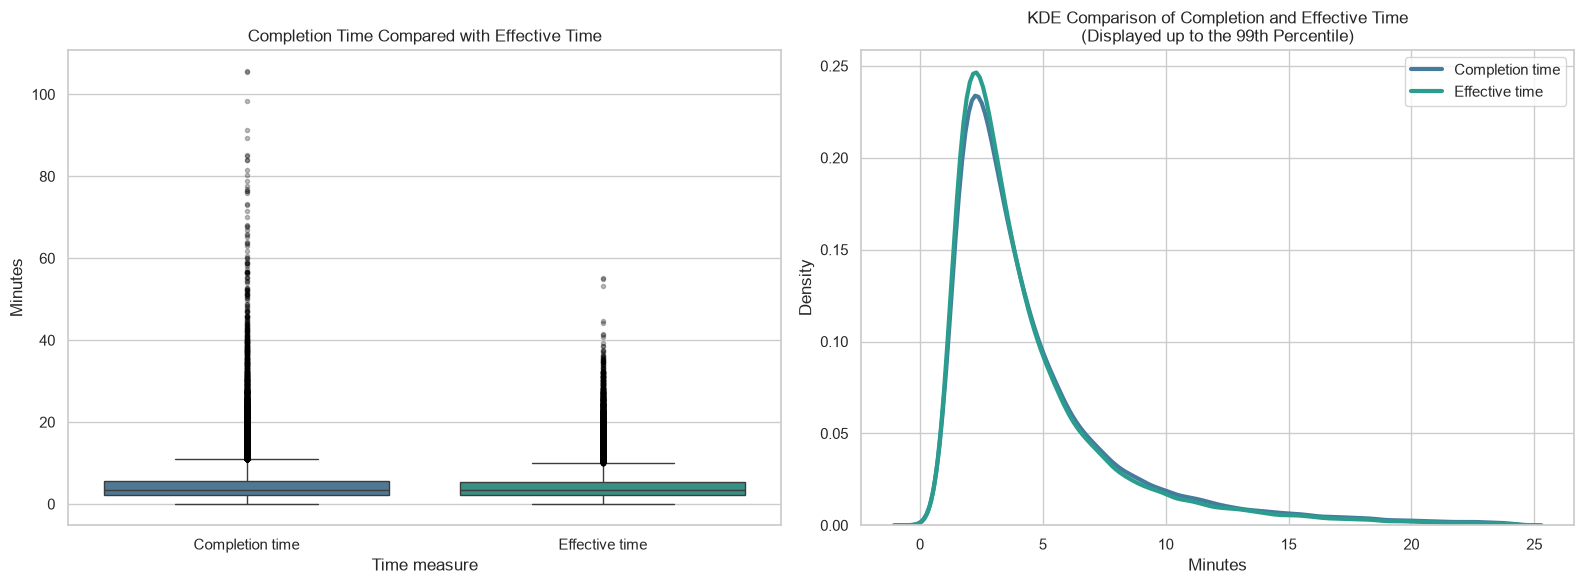

In [44]:
# Reshape the two time measures for comparative charts
time_comparison_long = (
    completed_time_kpis[
        [
            "completion_time_minutes",
            "effective_time_minutes"
        ]
    ]
    .rename(columns={
        "completion_time_minutes": "Completion time",
        "effective_time_minutes": "Effective time"
    })
    .melt(
        var_name="time_measure",
        value_name="minutes"
    )
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# Full-data comparative box plot
sns.boxplot(
    data=time_comparison_long,
    x="time_measure",
    y="minutes",
    hue="time_measure",
    legend=False,
    palette={
        "Completion time": "#457B9D",
        "Effective time": "#2A9D8F"
    },
    showfliers=True,
    flierprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 3,
        "alpha": 0.25
    },
    ax=axes[0]
)

axes[0].set_title("Completion Time Compared with Effective Time")
axes[0].set_xlabel("Time measure")
axes[0].set_ylabel("Minutes")

# KDE comparison up to the 99th percentile of completion time
time_display_limit = completed_time_kpis[
    "completion_time_minutes"
].quantile(0.99)

for column, label, colour in [
    (
        "completion_time_minutes",
        "Completion time",
        "#457B9D"
    ),
    (
        "effective_time_minutes",
        "Effective time",
        "#2A9D8F"
    )
]:
    display_values = completed_time_kpis.loc[
        completed_time_kpis[column] <= time_display_limit,
        column
    ]

    sns.kdeplot(
        x=display_values,
        linewidth=3,
        label=label,
        color=colour,
        ax=axes[1]
    )

axes[1].set_title(
    "KDE Comparison of Completion and Effective Time\n"
    "(Displayed up to the 99th Percentile)"
)
axes[1].set_xlabel("Minutes")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation of Completion Time and Effective Time

The box plots show that completion time and effective time have similar central distributions. Their medians and interquartile ranges are close, indicating that most successful customer journeys progress through the website with relatively little repeated, backward or inactive time.

The effective-time box is positioned slightly lower than the completion-time box because effective time excludes repeated steps, backward movements and gaps exceeding the inactivity threshold.

Both measures contain many upper outliers, confirming that their distributions are strongly right-skewed. However, the completion-time outliers extend beyond **100 minutes**, while effective-time outliers extend only to approximately **55 minutes**. This shows that some of the longest total journeys include substantial time that was not associated with active forward progression.

The KDE curves overlap closely across most of the distribution. Both curves peak at approximately three minutes and then decline gradually toward longer durations. The effective-time curve has a slightly higher and more concentrated peak, while the completion-time curve has a marginally heavier right tail.

This close overlap indicates that the typical completed journey is largely efficient. For most customers, total elapsed time and active forward-progression time are nearly the same.

The largest differences occur among non-standard journeys. These journeys may contain:

* Repeated steps
* Backward navigation
* Restarts
* Pauses or interruptions
* Long intervals before the next forward action

Therefore, effective time adds analytical value primarily by distinguishing unusually inefficient or interrupted journeys from the typical successful experience. It should be reported alongside completion time rather than used as a replacement.


### 7.5 Error Rate

The dataset does not contain a field showing confirmed technical errors. Therefore, error rate will be treated as a **navigation-difficulty proxy** rather than a direct measurement of website malfunction.

An event will be classified as a navigation error when:

* The customer repeats the immediately preceding process step, or
* The customer moves backwards to an earlier process step.

The first event in a journey will not be included in the denominator because it has no preceding event for comparison.

Repeated events and step-backs are mutually exclusive for an individual transition, so they can be combined without double-counting the same event.

The primary event-level error rate is:

> Number of repeated or backward transitions ÷ Total comparable transitions

Additional journey-level measures will include:

* Percentage of journeys containing at least one navigation error
* Average number of errors per journey
* Error rates for complete and incomplete journeys

These behaviours do not necessarily prove that a technical error occurred. Customers may deliberately review or correct information. Therefore, the KPI should be interpreted as evidence of possible friction or navigation difficulty.


In [45]:
# A comparable transition requires a preceding event
journey_events["comparable_transition"] = (
    journey_events["previous_step_number"].notna()
)

# Navigation-error proxy
journey_events["navigation_error"] = (
    journey_events["repeated_step"]
    | journey_events["step_back"]
)

total_comparable_transitions = (
    journey_events["comparable_transition"].sum()
)

total_navigation_errors = (
    journey_events["navigation_error"].sum()
)

overall_error_rate = (
    total_navigation_errors
    / total_comparable_transitions
    * 100
)

# Create journey-level error measures
journey_error_summary = (
    journey_events
    .groupby(journey_group)
    .agg(
        comparable_transitions=(
            "comparable_transition",
            "sum"
        ),
        navigation_errors=(
            "navigation_error",
            "sum"
        ),
        repeated_step_errors=(
            "repeated_step",
            "sum"
        ),
        step_back_errors=(
            "step_back",
            "sum"
        )
    )
    .reset_index()
)

journey_error_summary["has_navigation_error"] = (
    journey_error_summary["navigation_errors"] > 0
)

journey_error_summary["journey_error_rate_percent"] = np.where(
    journey_error_summary["comparable_transitions"] > 0,

    journey_error_summary["navigation_errors"]
    / journey_error_summary["comparable_transitions"]
    * 100,

    np.nan
)

# Add completion status for comparison
journey_error_summary = journey_error_summary.merge(
    client_visit_journeys[
        [
            "client_id",
            "visit_id",
            "completed"
        ]
    ],
    on=journey_group,
    how="left"
)

print(
    "Total comparable transitions:",
    total_comparable_transitions
)

print(
    "Total navigation-error events:",
    total_navigation_errors
)

print(
    "Overall event-level error rate:",
    round(overall_error_rate, 2),
    "%"
)

print(
    "Journeys containing at least one navigation error:",
    journey_error_summary[
        "has_navigation_error"
    ].sum()
)

print(
    "Percentage of journeys containing an error:",
    round(
        journey_error_summary[
            "has_navigation_error"
        ].mean() * 100,
        2
    ),
    "%"
)

# Compare complete and incomplete journeys
error_by_completion = (
    journey_error_summary
    .groupby("completed")
    .agg(
        number_of_journeys=("visit_id", "count"),
        journeys_with_errors=("has_navigation_error", "sum"),
        total_transitions=("comparable_transitions", "sum"),
        total_errors=("navigation_errors", "sum"),
        mean_errors_per_journey=("navigation_errors", "mean"),
        median_errors_per_journey=("navigation_errors", "median")
    )
    .reset_index()
)

error_by_completion["completion_status"] = np.where(
    error_by_completion["completed"],
    "Complete",
    "Incomplete"
)

error_by_completion["journeys_with_error_percent"] = (
    error_by_completion["journeys_with_errors"]
    / error_by_completion["number_of_journeys"]
    * 100
)

error_by_completion["event_error_rate_percent"] = (
    error_by_completion["total_errors"]
    / error_by_completion["total_transitions"]
    * 100
)

display(
    error_by_completion[
        [
            "completion_status",
            "number_of_journeys",
            "journeys_with_errors",
            "journeys_with_error_percent",
            "total_transitions",
            "total_errors",
            "event_error_rate_percent",
            "mean_errors_per_journey",
            "median_errors_per_journey"
        ]
    ].style.format({
        "number_of_journeys": "{:,.0f}",
        "journeys_with_errors": "{:,.0f}",
        "journeys_with_error_percent": "{:.2f}%",
        "total_transitions": "{:,.0f}",
        "total_errors": "{:,.0f}",
        "event_error_rate_percent": "{:.2f}%",
        "mean_errors_per_journey": "{:.2f}",
        "median_errors_per_journey": "{:.2f}"
    })
)

Total comparable transitions: 585529
Total navigation-error events: 140102
Overall event-level error rate: 23.93 %
Journeys containing at least one navigation error: 68157
Percentage of journeys containing an error: 42.84 %


,completion_status,number_of_journeys,journeys_with_errors,journeys_with_error_percent,total_transitions,total_errors,event_error_rate_percent,mean_errors_per_journey,median_errors_per_journey
0,Incomplete,"68,474","34,589",50.51%,"175,081","76,922",43.94%,1.12,1.00
1,Complete,"90,638","33,568",37.04%,"410,448","63,180",15.39%,0.70,0.00


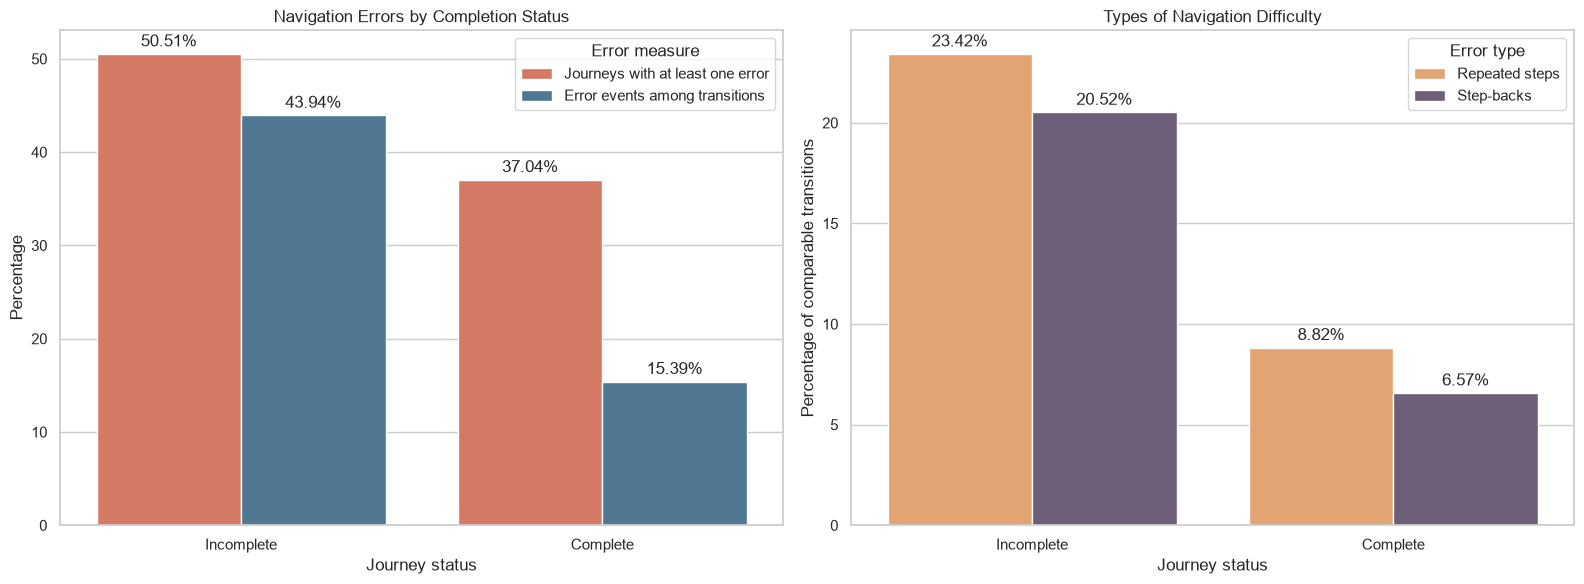

In [46]:
# Prepare the main error-rate comparison
error_rate_chart_data = error_by_completion[
    [
        "completion_status",
        "journeys_with_error_percent",
        "event_error_rate_percent"
    ]
].melt(
    id_vars="completion_status",
    var_name="error_measure",
    value_name="percentage"
)

error_rate_chart_data["error_measure"] = (
    error_rate_chart_data["error_measure"]
    .map({
        "journeys_with_error_percent":
            "Journeys with at least one error",

        "event_error_rate_percent":
            "Error events among transitions"
    })
)

# Calculate repeated-step and step-back rates separately
error_type_by_completion = (
    journey_error_summary
    .groupby("completed")
    .agg(
        total_transitions=("comparable_transitions", "sum"),
        repeated_steps=("repeated_step_errors", "sum"),
        step_backs=("step_back_errors", "sum")
    )
    .reset_index()
)

error_type_by_completion["completion_status"] = np.where(
    error_type_by_completion["completed"],
    "Complete",
    "Incomplete"
)

error_type_by_completion["repeated_step_rate"] = (
    error_type_by_completion["repeated_steps"]
    / error_type_by_completion["total_transitions"]
    * 100
)

error_type_by_completion["step_back_rate"] = (
    error_type_by_completion["step_backs"]
    / error_type_by_completion["total_transitions"]
    * 100
)

error_type_chart_data = error_type_by_completion[
    [
        "completion_status",
        "repeated_step_rate",
        "step_back_rate"
    ]
].melt(
    id_vars="completion_status",
    var_name="error_type",
    value_name="percentage"
)

error_type_chart_data["error_type"] = (
    error_type_chart_data["error_type"]
    .map({
        "repeated_step_rate": "Repeated steps",
        "step_back_rate": "Step-backs"
    })
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# Chart 1: overall error measures
sns.barplot(
    data=error_rate_chart_data,
    x="completion_status",
    y="percentage",
    hue="error_measure",
    palette=["#E76F51", "#457B9D"],
    ax=axes[0]
)

axes[0].set_title("Navigation Errors by Completion Status")
axes[0].set_xlabel("Journey status")
axes[0].set_ylabel("Percentage")
axes[0].legend(title="Error measure")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

# Chart 2: error-type comparison
sns.barplot(
    data=error_type_chart_data,
    x="completion_status",
    y="percentage",
    hue="error_type",
    palette=["#F4A261", "#6C5B7B"],
    ax=axes[1]
)

axes[1].set_title("Types of Navigation Difficulty")
axes[1].set_xlabel("Journey status")
axes[1].set_ylabel("Percentage of comparable transitions")
axes[1].legend(title="Error type")

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Error-Rate Results and Chart Interpretation

Across all client-visit journeys, **140,102 of 585,529 comparable transitions** are classified as repeated or backward movements. This produces an overall event-level navigation-error rate of **23.93%**.

At the journey level, **68,157 journeys**, or **42.84%**, contain at least one navigation-error event.

The first chart shows a clear difference between incomplete and complete journeys:

* **50.51%** of incomplete journeys contain at least one navigation error.
* **37.04%** of complete journeys contain at least one navigation error.
* **43.94%** of transitions in incomplete journeys are classified as errors.
* Only **15.39%** of transitions in complete journeys are classified as errors.

The gap between the journey-level and transition-level measures is especially large for completed journeys. Although 37.04% of completed journeys contain at least one error, errors represent only 15.39% of their transitions. This suggests that many completed customers encounter occasional navigation difficulty but successfully recover and continue.

The second chart separates navigation errors into repeated steps and step-backs.

For incomplete journeys:

* **23.42%** of comparable transitions are repeated steps.
* **20.52%** are backward movements.

For complete journeys:

* **8.82%** of transitions are repeated steps.
* **6.57%** are backward movements.

Repeated steps are more common than step-backs in both groups. However, both behaviours occur approximately three times as frequently among incomplete journeys as among completed journeys.

These results suggest that customers who repeat steps or move backwards are less likely to complete the process. The relationship is particularly strong for incomplete journeys, where almost 44% of comparable transitions show potential navigation difficulty.

The results demonstrate association rather than causation. Repeated steps may reflect page refreshes, duplicate tracking or deliberate review, while step-backs may represent customers correcting information. Therefore, the KPI should be described as a **navigation-difficulty proxy**, not a confirmed technical-error rate.

During the Control-versus-Test comparison, lower repeated-step and step-back rates would provide evidence that the new design offers a smoother customer experience.


### 7.6 Step-Backs

A step-back occurs when a customer moves from a later process stage to an earlier stage.

Examples include:

* `step_3 → step_2`: backward distance of one stage
* `step_3 → step_1`: backward distance of two stages
* `confirm → start`: backward distance of four stages

The primary step-back KPI counts every backward transition individually.

Additional measures will include:

* Percentage of comparable transitions that are step-backs
* Percentage of journeys containing at least one step-back
* Average and median number of step-backs per journey
* Distance moved backwards
* Most frequent backward transition
* Comparison between complete and incomplete journeys

Every backward movement receives a count of one in the primary frequency KPI. The backward distance is preserved as a secondary severity measure so that a one-stage correction can be distinguished from a complete restart.


In [47]:
# Create a readable previous-step label
number_to_step = {
    0: "start",
    1: "step_1",
    2: "step_2",
    3: "step_3",
    4: "confirm"
}

journey_events["previous_process_step"] = (
    journey_events["previous_step_number"]
    .map(number_to_step)
)

# Select all backward transitions
step_back_events = (
    journey_events[
        journey_events["step_back"]
    ]
    .copy()
)

step_back_events["step_back_transition"] = (
    step_back_events["previous_process_step"]
    + " → "
    + step_back_events["process_step"]
)

# Overall step-back statistics
total_step_backs = len(step_back_events)

journeys_with_step_backs = (
    journey_error_summary[
        "step_back_errors"
    ].gt(0).sum()
)

overall_step_back_rate = (
    total_step_backs
    / total_comparable_transitions
    * 100
)

journeys_with_step_back_percent = (
    journeys_with_step_backs
    / len(journey_error_summary)
    * 100
)

print("Total step-back events:", total_step_backs)

print(
    "Overall step-back rate:",
    round(overall_step_back_rate, 2),
    "%"
)

print(
    "Journeys with at least one step-back:",
    journeys_with_step_backs
)

print(
    "Percentage of journeys with a step-back:",
    round(journeys_with_step_back_percent, 2),
    "%"
)

print("\nStep-back distance summary:")

display(
    step_back_events[
        "step_back_distance"
    ].describe().round(2)
)

# Count the specific backward transitions
step_back_transition_summary = (
    step_back_events[
        "step_back_transition"
    ]
    .value_counts()
    .rename_axis("step_back_transition")
    .reset_index(name="number_of_step_backs")
)

step_back_transition_summary[
    "percentage_of_step_backs"
] = (
    step_back_transition_summary[
        "number_of_step_backs"
    ]
    / total_step_backs
    * 100
)

display(
    step_back_transition_summary.style.format({
        "number_of_step_backs": "{:,.0f}",
        "percentage_of_step_backs": "{:.2f}%"
    })
)

# Compare complete and incomplete journeys
step_back_by_completion = (
    journey_error_summary
    .groupby("completed")
    .agg(
        number_of_journeys=("visit_id", "count"),
        total_transitions=("comparable_transitions", "sum"),
        total_step_backs=("step_back_errors", "sum"),
        journeys_with_step_backs=(
            "step_back_errors",
            lambda x: x.gt(0).sum()
        ),
        mean_step_backs_per_journey=(
            "step_back_errors",
            "mean"
        ),
        median_step_backs_per_journey=(
            "step_back_errors",
            "median"
        )
    )
    .reset_index()
)

step_back_by_completion["completion_status"] = np.where(
    step_back_by_completion["completed"],
    "Complete",
    "Incomplete"
)

step_back_by_completion["step_back_rate_percent"] = (
    step_back_by_completion["total_step_backs"]
    / step_back_by_completion["total_transitions"]
    * 100
)

step_back_by_completion[
    "journeys_with_step_back_percent"
] = (
    step_back_by_completion["journeys_with_step_backs"]
    / step_back_by_completion["number_of_journeys"]
    * 100
)

display(
    step_back_by_completion[
        [
            "completion_status",
            "number_of_journeys",
            "total_step_backs",
            "step_back_rate_percent",
            "journeys_with_step_backs",
            "journeys_with_step_back_percent",
            "mean_step_backs_per_journey",
            "median_step_backs_per_journey"
        ]
    ].style.format({
        "number_of_journeys": "{:,.0f}",
        "total_step_backs": "{:,.0f}",
        "step_back_rate_percent": "{:.2f}%",
        "journeys_with_step_backs": "{:,.0f}",
        "journeys_with_step_back_percent": "{:.2f}%",
        "mean_step_backs_per_journey": "{:.2f}",
        "median_step_backs_per_journey": "{:.2f}"
    })
)

Total step-back events: 62880
Overall step-back rate: 10.74 %
Journeys with at least one step-back: 39949
Percentage of journeys with a step-back: 25.11 %

Step-back distance summary:


count    62880.00
mean         1.45
std          0.80
min          1.00
25%          1.00
50%          1.00
75%          2.00
max          4.00
Name: step_back_distance, dtype: float64

,step_back_transition,number_of_step_backs,percentage_of_step_backs
0,step_1 → start,"23,587",37.51%
1,step_2 → step_1,"12,171",19.36%
2,step_3 → step_2,"9,418",14.98%
3,step_3 → start,"8,265",13.14%
4,step_2 → start,"5,940",9.45%
5,step_3 → step_1,"1,637",2.60%
6,confirm → start,"1,109",1.76%
7,confirm → step_1,552,0.88%
8,confirm → step_3,194,0.31%
9,confirm → step_2,7,0.01%


,completion_status,number_of_journeys,total_step_backs,step_back_rate_percent,journeys_with_step_backs,journeys_with_step_back_percent,mean_step_backs_per_journey,median_step_backs_per_journey
0,Incomplete,"68,474","35,921",20.52%,"21,094",30.81%,0.52,0.00
1,Complete,"90,638","26,959",6.57%,"18,855",20.80%,0.30,0.00


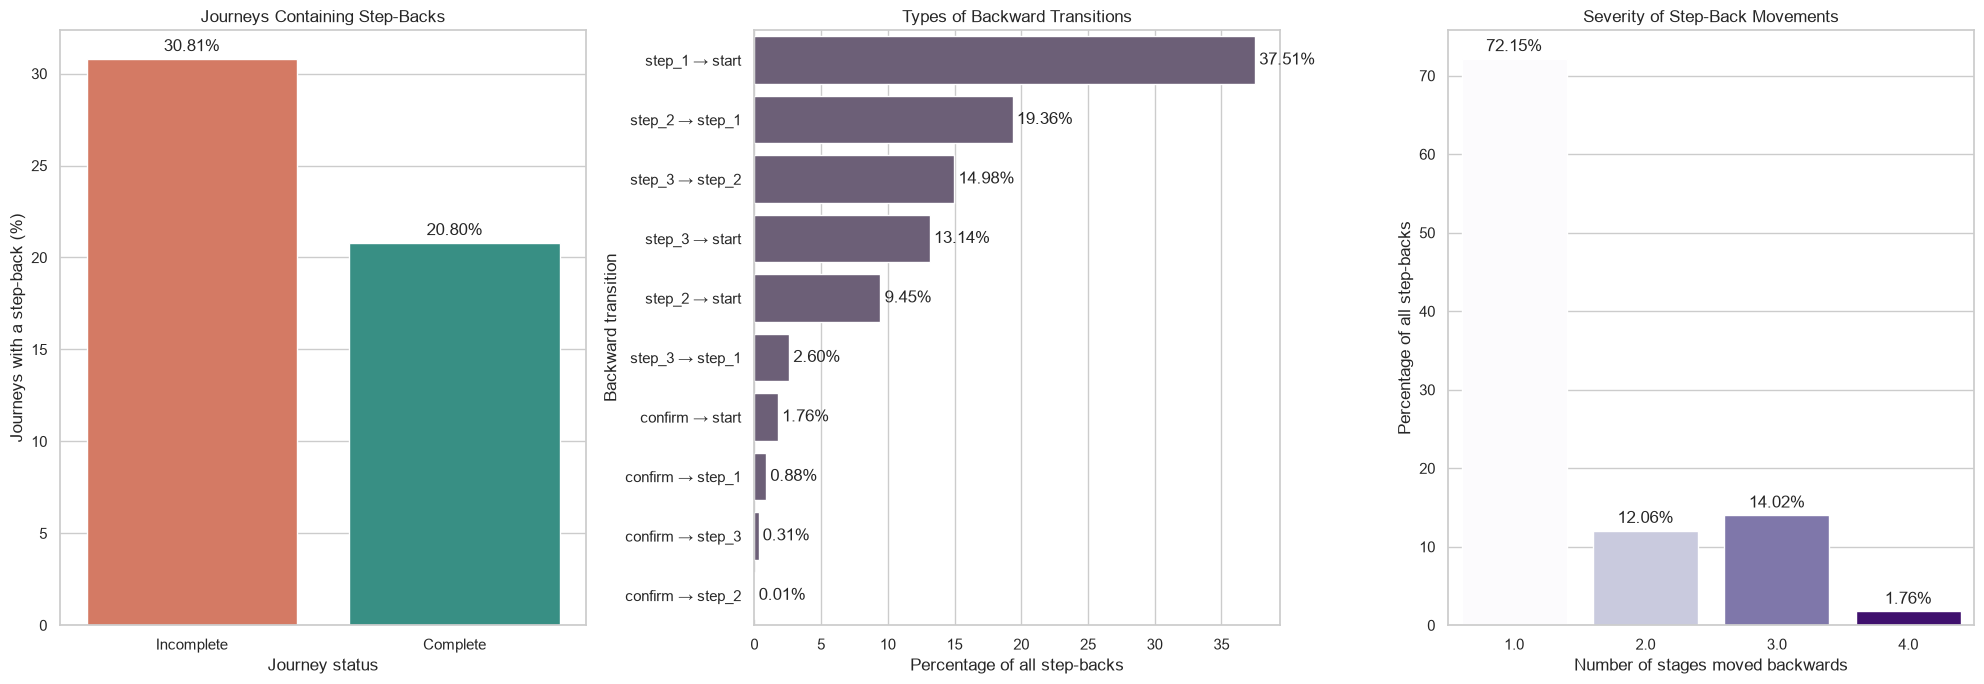

In [48]:
# Step-back distance distribution
step_back_distance_summary = (
    step_back_events["step_back_distance"]
    .value_counts()
    .sort_index()
    .rename_axis("step_back_distance")
    .reset_index(name="number_of_step_backs")
)

step_back_distance_summary["percentage_of_step_backs"] = (
    step_back_distance_summary["number_of_step_backs"]
    / total_step_backs
    * 100
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 7)
)

# Chart 1: Journey prevalence by completion status
sns.barplot(
    data=step_back_by_completion,
    x="completion_status",
    y="journeys_with_step_back_percent",
    hue="completion_status",
    legend=False,
    palette={
        "Incomplete": "#E76F51",
        "Complete": "#2A9D8F"
    },
    ax=axes[0]
)

axes[0].set_title("Journeys Containing Step-Backs")
axes[0].set_xlabel("Journey status")
axes[0].set_ylabel("Journeys with a step-back (%)")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

# Chart 2: Specific backward transitions
sns.barplot(
    data=step_back_transition_summary,
    x="percentage_of_step_backs",
    y="step_back_transition",
    color="#6C5B7B",
    ax=axes[1]
)

axes[1].set_title("Types of Backward Transitions")
axes[1].set_xlabel("Percentage of all step-backs")
axes[1].set_ylabel("Backward transition")

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

# Chart 3: Backward-distance severity
sns.barplot(
    data=step_back_distance_summary,
    x="step_back_distance",
    y="percentage_of_step_backs",
    hue="step_back_distance",
    legend=False,
    palette="Purples",
    ax=axes[2]
)

axes[2].set_title("Severity of Step-Back Movements")
axes[2].set_xlabel("Number of stages moved backwards")
axes[2].set_ylabel("Percentage of all step-backs")

for container in axes[2].containers:
    axes[2].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Step-Back Results and Chart Interpretation

A total of **62,880 backward transitions** were identified. Step-backs represent **10.74%** of all comparable transitions, and **25.11%** of client-visit journeys contain at least one step-back.

The first chart shows that backward navigation is more common among incomplete journeys:

* **30.81%** of incomplete journeys contain at least one step-back.
* **20.80%** of complete journeys contain at least one step-back.

This difference of approximately ten percentage points suggests an association between backward navigation and failure to complete the process. However, some customers successfully recover from a step-back and eventually reach confirmation.

The most common backward transition is:

> `step_1 → start`

This transition accounts for **37.51%** of all step-backs. Its high frequency suggests that a considerable number of customers return to the beginning shortly after entering the first stage.

Other common backward transitions are:

* `step_2 → step_1`: **19.36%**
* `step_3 → step_2`: **14.98%**
* `step_3 → start`: **13.14%**
* `step_2 → start`: **9.45%**

Backward movements after confirmation are relatively uncommon. For example, `confirm → start` represents only **1.76%** of all step-backs.

The severity chart shows that most backward movements are small:

* **72.15%** move backwards by one stage.
* **12.06%** move backwards by two stages.
* **14.02%** move backwards by three stages.
* **1.76%** move backwards by four stages.

Therefore, **84.21%** of all step-backs involve no more than two stages. These movements are more likely to represent local corrections or reviews.

However, **15.78%** of step-backs move backwards by three or four stages. These larger movements represent substantial restarts and may indicate stronger navigation difficulty, loss of entered information or a decision to begin the process again.

The dominant `step_1 → start` transition and the higher prevalence of step-backs in incomplete journeys suggest that the early stages of the website process deserve particular attention.

Nevertheless, a backward movement does not prove that the website malfunctioned. Customers may intentionally return to correct information. The primary KPI therefore counts each step-back once, while backward distance provides a secondary measure of severity.


### 7.7 Abandonment Rate

Abandonment rate measures the proportion of started client-visit journeys that do not subsequently reach confirmation.

A journey will be classified as abandoned when:

* It contains at least one recorded `start`, and
* No `confirm` occurs chronologically after a recorded start.

Journeys without a recorded start are excluded because it cannot be established that an observable process attempt began.

Each client-visit journey is treated as a separate attempt. Therefore, a client may abandon one journey and later complete the process in another journey. Journey abandonment should not automatically be interpreted as permanent customer failure.

The furthest sequential stage reached before abandonment will also be identified to show where unsuccessful journeys ended.


In [49]:
# Add valid chronological completion to the funnel dataset
abandonment_summary = journey_funnel.merge(
    completion_time_summary[
        [
            "client_id",
            "visit_id",
            "completion_time_minutes"
        ]
    ],
    on=journey_group,
    how="left"
)

abandonment_summary["valid_completion"] = (
    abandonment_summary[
        "completion_time_minutes"
    ].notna()
)

# Abandonment requires a recorded start and no later confirmation
abandonment_summary["abandoned"] = (
    abandonment_summary["reached_start"]
    & ~abandonment_summary["valid_completion"]
)

started_journeys = (
    abandonment_summary["reached_start"].sum()
)

abandoned_journeys = (
    abandonment_summary["abandoned"].sum()
)

abandonment_rate = (
    abandoned_journeys
    / started_journeys
    * 100
)

print("Started client-visit journeys:", started_journeys)
print("Abandoned client-visit journeys:", abandoned_journeys)

print(
    "Journey-level abandonment rate:",
    round(abandonment_rate, 2),
    "%"
)

# Identify the furthest ordered stage reached
abandonment_summary["furthest_stage_reached"] = np.select(
    [
        abandonment_summary["reached_step_3"],
        abandonment_summary["reached_step_2"],
        abandonment_summary["reached_step_1"],
        abandonment_summary["reached_start"]
    ],
    [
        "Step 3",
        "Step 2",
        "Step 1",
        "Start only"
    ],
    default="No recorded start"
)

# Summarise only abandoned journeys
abandonment_stage_summary = (
    abandonment_summary[
        abandonment_summary["abandoned"]
    ]["furthest_stage_reached"]
    .value_counts()
    .reindex(
        [
            "Start only",
            "Step 1",
            "Step 2",
            "Step 3"
        ],
        fill_value=0
    )
    .rename_axis("furthest_stage_reached")
    .reset_index(name="abandoned_journeys")
)

abandonment_stage_summary[
    "percentage_of_abandoned_journeys"
] = (
    abandonment_stage_summary[
        "abandoned_journeys"
    ]
    / abandoned_journeys
    * 100
)

display(
    abandonment_stage_summary.style.format({
        "abandoned_journeys": "{:,.0f}",
        "percentage_of_abandoned_journeys": "{:.2f}%"
    })
)

Started client-visit journeys: 145835
Abandoned client-visit journeys: 67830
Journey-level abandonment rate: 46.51 %


,furthest_stage_reached,abandoned_journeys,percentage_of_abandoned_journeys
0,Start only,"27,189",40.08%
1,Step 1,"15,369",22.66%
2,Step 2,"10,225",15.07%
3,Step 3,"15,047",22.18%


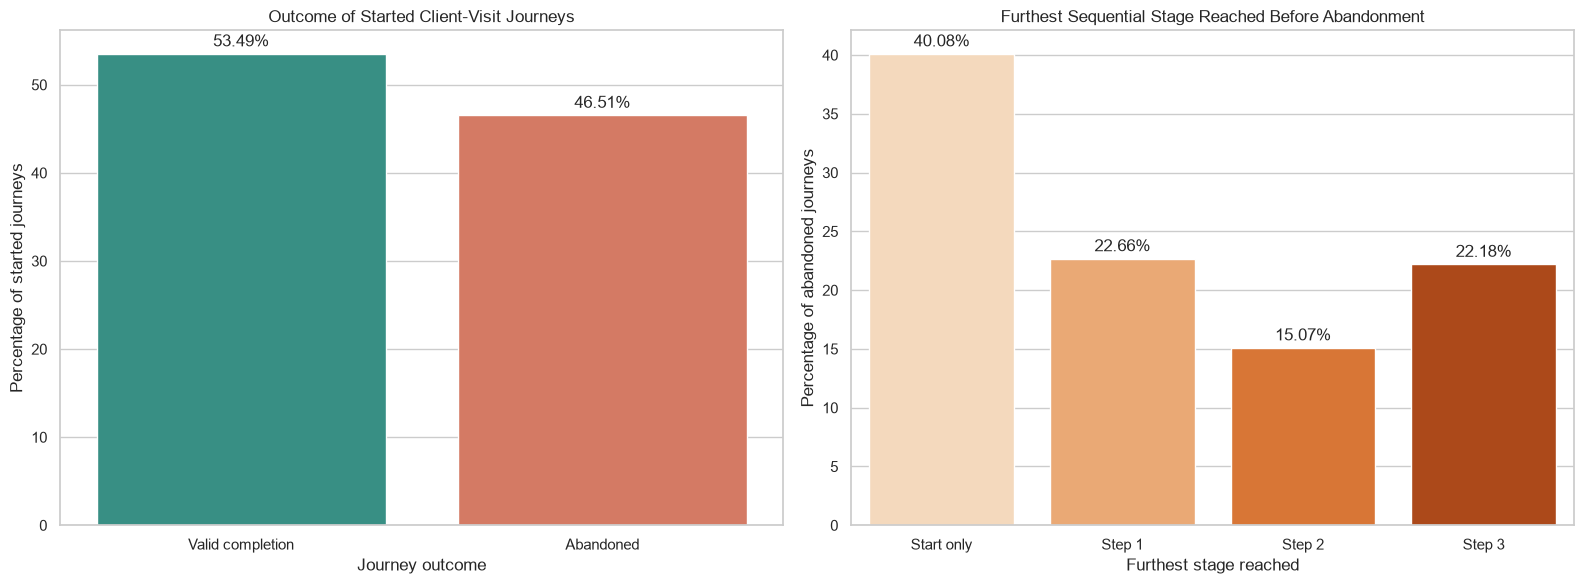

In [50]:
valid_completed_started = (
    started_journeys
    - abandoned_journeys
)

started_outcome_summary = pd.DataFrame({
    "journey_outcome": [
        "Valid completion",
        "Abandoned"
    ],

    "number_of_journeys": [
        valid_completed_started,
        abandoned_journeys
    ]
})

started_outcome_summary["percentage"] = (
    started_outcome_summary["number_of_journeys"]
    / started_journeys
    * 100
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# Chart 1: completion versus abandonment
sns.barplot(
    data=started_outcome_summary,
    x="journey_outcome",
    y="percentage",
    hue="journey_outcome",
    legend=False,
    palette={
        "Valid completion": "#2A9D8F",
        "Abandoned": "#E76F51"
    },
    ax=axes[0]
)

axes[0].set_title("Outcome of Started Client-Visit Journeys")
axes[0].set_xlabel("Journey outcome")
axes[0].set_ylabel("Percentage of started journeys")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

# Chart 2: furthest stage reached before abandonment
sns.barplot(
    data=abandonment_stage_summary,
    x="furthest_stage_reached",
    y="percentage_of_abandoned_journeys",
    hue="furthest_stage_reached",
    legend=False,
    palette="Oranges",
    ax=axes[1]
)

axes[1].set_title("Furthest Sequential Stage Reached Before Abandonment")
axes[1].set_xlabel("Furthest stage reached")
axes[1].set_ylabel("Percentage of abandoned journeys")

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Abandonment-Rate Results and Interpretation

Of the **145,835 client-visit journeys** containing a recorded start, **67,830** do not contain a confirmation occurring after that start. This produces a journey-level abandonment rate of **46.51%**.

The corresponding valid chronological completion rate is **53.49%**. This is slightly lower than the earlier broad started-journey completion rate of 53.53% because 60 journeys contain both start and confirmation but do not record confirmation after start in chronological order.

The furthest-stage analysis shows that abandonment is concentrated at both the beginning and the end of the process:

* **40.08%** of abandoned journeys do not progress beyond `start`.
* **22.66%** reach `step_1`.
* **15.07%** reach `step_2`.
* **22.18%** reach `step_3` but do not confirm.

Together, **62.74%** of abandoned journeys end at `start` or `step_1`. This suggests that the beginning of the process is the main abandonment area and supports the earlier funnel result, where the largest transition drop-off occurred between `start` and `step_1`.

The **22.18%** of abandoned journeys that reach `step_3` are also important. These customers progress through most of the process but leave immediately before confirmation. This supports investigating the final confirmation stage for possible friction, uncertainty or technical difficulty.

Abandonment is measured at the journey level rather than as permanent client failure. A customer may abandon one visit and later complete the process during another. Therefore:

* Journey-level abandonment measures unsuccessful website attempts.
* Client-level completion measures whether a customer eventually succeeds.

Both measures are needed to describe customer behaviour accurately.


## 8. Building and Validating the Final KPI Dataset

The journey-level measures will now be combined into one analytical dataset containing one row per `client_id` and `visit_id`.

This dataset will support:

* KPI validation
* Control-versus-Test comparisons
* Statistical testing
* Tableau visualisation
* Final business recommendations

Validation checks will confirm:

* The client-visit key is unique.
* Durations are non-negative.
* Effective time does not exceed completion time.
* Ordered funnel stages are logically consistent.
* Completed and abandoned classifications do not conflict.
* Missing completion times occur only where the required start-to-confirm sequence was not observed.


In [51]:
# Start with the main client-visit dataset
journey_kpis = (
    client_visit_journeys
    .rename(columns={
        "effective_time_minutes":
            "all_journey_forward_time_minutes"
    })
    .copy()
)

# Add ordered-funnel variables
journey_kpis = journey_kpis.merge(
    journey_funnel,
    on=journey_group,
    how="left"
)

# Add completion-time and successful-attempt effective-time variables
journey_kpis = journey_kpis.merge(
    completion_time_summary[
        [
            "client_id",
            "visit_id",
            "first_valid_confirm_time",
            "last_start_before_confirm",
            "completion_time_minutes",
            "effective_time_minutes",
            "interrupted_during_attempt"
        ]
    ],
    on=journey_group,
    how="left"
)

# Add navigation-error variables
journey_kpis = journey_kpis.merge(
    journey_error_summary[
        [
            "client_id",
            "visit_id",
            "comparable_transitions",
            "navigation_errors",
            "repeated_step_errors",
            "step_back_errors",
            "has_navigation_error"
        ]
    ],
    on=journey_group,
    how="left"
)

# Add abandonment variables
journey_kpis = journey_kpis.merge(
    abandonment_summary[
        [
            "client_id",
            "visit_id",
            "valid_completion",
            "abandoned",
            "furthest_stage_reached"
        ]
    ],
    on=journey_group,
    how="left"
)

# Calculate journey-specific rates
journey_kpis["navigation_error_rate_percent"] = np.where(
    journey_kpis["comparable_transitions"] > 0,

    journey_kpis["navigation_errors"]
    / journey_kpis["comparable_transitions"]
    * 100,

    np.nan
)

journey_kpis["step_back_rate_percent"] = np.where(
    journey_kpis["comparable_transitions"] > 0,

    journey_kpis["step_back_errors"]
    / journey_kpis["comparable_transitions"]
    * 100,

    np.nan
)

journey_kpis["repeated_step_rate_percent"] = np.where(
    journey_kpis["comparable_transitions"] > 0,

    journey_kpis["repeated_step_errors"]
    / journey_kpis["comparable_transitions"]
    * 100,

    np.nan
)

# Abandonment is applicable only to journeys with a recorded start
journey_kpis["abandonment_eligible"] = (
    journey_kpis["reached_start"]
)

# -----------------------------
# Validation checks
# -----------------------------

print("Final journey KPI shape:", journey_kpis.shape)

print(
    "Duplicated client-visit keys:",
    journey_kpis.duplicated(
        subset=journey_group
    ).sum()
)

print(
    "Negative journey durations:",
    journey_kpis["duration_minutes"].lt(0).sum()
)

print(
    "Negative completion times:",
    journey_kpis[
        "completion_time_minutes"
    ].lt(0).sum()
)

print(
    "Effective time greater than completion time:",
    (
        journey_kpis["effective_time_minutes"]
        > journey_kpis["completion_time_minutes"]
    ).sum()
)

print(
    "Valid completions without a recorded start:",
    (
        journey_kpis["valid_completion"]
        & ~journey_kpis["reached_start"]
    ).sum()
)

print(
    "Journeys classified as both completed and abandoned:",
    (
        journey_kpis["valid_completion"]
        & journey_kpis["abandoned"]
    ).sum()
)

print(
    "Step 1 reached without Start:",
    (
        journey_kpis["reached_step_1"]
        & ~journey_kpis["reached_start"]
    ).sum()
)

print(
    "Step 2 reached without Step 1:",
    (
        journey_kpis["reached_step_2"]
        & ~journey_kpis["reached_step_1"]
    ).sum()
)

print(
    "Step 3 reached without Step 2:",
    (
        journey_kpis["reached_step_3"]
        & ~journey_kpis["reached_step_2"]
    ).sum()
)

print(
    "Ordered Confirm reached without Step 3:",
    (
        journey_kpis["reached_confirm"]
        & ~journey_kpis["reached_step_3"]
    ).sum()
)

journey_kpis.head()

Final journey KPI shape: (159112, 42)
Duplicated client-visit keys: 0
Negative journey durations: 0
Negative completion times: 0
Effective time greater than completion time: 8419
Valid completions without a recorded start: 0
Journeys classified as both completed and abandoned: 0
Step 1 reached without Start: 0
Step 2 reached without Step 1: 0
Step 3 reached without Step 2: 0
Ordered Confirm reached without Step 3: 0


,client_id,visit_id,visitor_id,number_of_visitors,journey_start,journey_end,number_of_events,journey_sequence,number_of_starts,number_of_confirms,repeated_steps,step_backs,total_step_back_distance,number_of_interruptions,all_journey_forward_time_minutes,duration_minutes,completed,interrupted,has_recorded_start,started_and_completed,reached_start,reached_step_1,reached_step_2,reached_step_3,reached_confirm,first_valid_confirm_time,last_start_before_confirm,completion_time_minutes,effective_time_minutes,interrupted_during_attempt,comparable_transitions,navigation_errors,repeated_step_errors,step_back_errors,has_navigation_error,valid_completion,abandoned,furthest_stage_reached,navigation_error_rate_percent,step_back_rate_percent,repeated_step_rate_percent,abandonment_eligible
0,169,749567106_99161211863_557568,201385055_71273495308,1,2017-04-12 20:19:36,2017-04-12 20:23:09,5,"[start, step_1, step_2, step_3, confirm]",1,1,0,0,0.0,0,3.550000,3.550000,True,False,True,True,True,True,True,True,True,2017-04-12 20:23:09,2017-04-12 20:19:36,3.550000,3.550000,False,4,0,0,0,False,True,False,Step 3,0.0,0.0,0.0,True
1,336,649044751_80905125055_554468,64757908_3400128256,1,2017-06-01 07:26:55,2017-06-01 07:42:43,2,"[start, start]",2,0,1,0,0.0,0,0.000000,15.800000,False,False,True,False,True,False,False,False,False,NaT,NaT,NaN,0.000000,False,1,1,1,0,True,False,True,Start only,100.0,0.0,100.0,True
2,546,731811517_9330176838_94847,475037402_89828530214,1,2017-06-17 10:03:29,2017-06-17 10:05:42,5,"[start, step_1, step_2, step_3, confirm]",1,1,0,0,0.0,0,2.216667,2.216667,True,False,True,True,True,True,True,True,True,2017-06-17 10:05:42,2017-06-17 10:03:29,2.216667,2.216667,False,4,0,0,0,False,True,False,Step 3,0.0,0.0,0.0,True
3,555,637149525_38041617439_716659,402506806_56087378777,1,2017-04-15 12:57:56,2017-04-15 13:00:34,5,"[start, step_1, step_2, step_3, confirm]",1,1,0,0,0.0,0,2.633333,2.633333,True,False,True,True,True,True,True,True,True,2017-04-15 13:00:34,2017-04-15 12:57:56,2.633333,2.633333,False,4,0,0,0,False,True,False,Step 3,0.0,0.0,0.0,True
4,647,40369564_40101682850_311847,66758770_53988066587,1,2017-04-12 15:41:28,2017-04-12 15:47:45,5,"[start, step_1, step_2, step_3, confirm]",1,1,0,0,0.0,0,6.283333,6.283333,True,False,True,True,True,True,True,True,True,2017-04-12 15:47:45,2017-04-12 15:41:28,6.283333,6.283333,False,4,0,0,0,False,True,False,Step 3,0.0,0.0,0.0,True


In [52]:
journey_kpis["effective_time_excess"] = (
    journey_kpis["effective_time_minutes"]
    - journey_kpis["completion_time_minutes"]
)

positive_excess = journey_kpis.loc[
    journey_kpis["effective_time_excess"] > 0,
    "effective_time_excess"
]

print(
    "Journeys with any positive excess:",
    positive_excess.count()
)

print(
    "Excess greater than 0.000001 minutes:",
    positive_excess.gt(0.000001).sum()
)

print(
    "Excess greater than 0.01 minutes:",
    positive_excess.gt(0.01).sum()
)

print(
    "Excess greater than 1 minute:",
    positive_excess.gt(1).sum()
)

print("\nPositive-excess summary:")
display(
    positive_excess.describe().round(10)
)

Journeys with any positive excess: 8419
Excess greater than 0.000001 minutes: 0
Excess greater than 0.01 minutes: 0
Excess greater than 1 minute: 0

Positive-excess summary:


count    8419.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: effective_time_excess, dtype: float64

In [53]:
# Identify only negligible floating-point differences
floating_point_mask = (
    journey_kpis["effective_time_minutes"]
    > journey_kpis["completion_time_minutes"]
) & np.isclose(
    journey_kpis["effective_time_minutes"],
    journey_kpis["completion_time_minutes"],
    atol=0.000001
)

print(
    "Values corrected for floating-point precision:",
    floating_point_mask.sum()
)

# Set mathematically equal values to exactly the completion time
journey_kpis.loc[
    floating_point_mask,
    "effective_time_minutes"
] = journey_kpis.loc[
    floating_point_mask,
    "completion_time_minutes"
]

# Remove the temporary diagnostic column
journey_kpis = journey_kpis.drop(
    columns="effective_time_excess"
)

# Validate again using a practical tolerance
material_time_violations = (
    journey_kpis["effective_time_minutes"]
    > journey_kpis["completion_time_minutes"] + 0.000001
).sum()

print(
    "Material effective-time violations remaining:",
    material_time_violations
)

Values corrected for floating-point precision: 8419
Material effective-time violations remaining: 0


### Floating-Point Precision Correction

The initial validation identified 8,419 journeys where effective time appeared to be slightly greater than completion time.

Further investigation showed that none of the differences exceeded **0.000001 minutes**. The apparent violations were therefore caused by floating-point precision rather than errors in the KPI methodology.

Computers store many decimal values as binary approximations. As a result, two values that are mathematically equal may differ by an extremely small amount internally.

Values within a tolerance of 0.000001 minutes were treated as equal and set to the corresponding completion time. After this correction, no material cases remain where effective time exceeds completion time.

This correction does not materially alter any journey duration or KPI result; it only ensures logical consistency in the final analytical dataset.


### Missing-Value Validation

Missing values in the final KPI dataset are not automatically data-quality problems.

Some values are undefined because a KPI is not applicable:

* Incomplete journeys do not have completion time.
* Confirmation-only journeys do not have a measurable start-to-confirm duration.
* Single-event journeys do not have comparable transitions, so their journey-level error rate is undefined.
* Journeys without a valid successful attempt do not have successful-attempt effective time.

The missing-value pattern will be inspected to distinguish expected methodological missingness from unexpected data loss.


In [54]:
missing_kpi_summary = pd.DataFrame({
    "missing_values": journey_kpis.isna().sum(),
    "missing_percentage": (
        journey_kpis.isna().mean() * 100
    )
})

missing_kpi_summary = (
    missing_kpi_summary[
        missing_kpi_summary["missing_values"] > 0
    ]
    .sort_values(
        "missing_values",
        ascending=False
    )
)

display(
    missing_kpi_summary.style.format({
        "missing_values": "{:,.0f}",
        "missing_percentage": "{:.2f}%"
    })
)

# Validate expected missing completion times
missing_completion_time = (
    journey_kpis["completion_time_minutes"].isna()
)

print(
    "Missing completion times:",
    missing_completion_time.sum()
)

print(
    "Missing completion times with valid_completion = True:",
    (
        missing_completion_time
        & journey_kpis["valid_completion"]
    ).sum()
)

print(
    "Non-missing completion times with valid_completion = False:",
    (
        journey_kpis["completion_time_minutes"].notna()
        & ~journey_kpis["valid_completion"]
    ).sum()
)

# Validate missing error rates
missing_error_rate = (
    journey_kpis["navigation_error_rate_percent"].isna()
)

print(
    "Missing navigation-error rates:",
    missing_error_rate.sum()
)

print(
    "Missing error rates with comparable transitions:",
    (
        missing_error_rate
        & journey_kpis["comparable_transitions"].gt(0)
    ).sum()
)

,missing_values,missing_percentage
first_valid_confirm_time,"81,107",50.97%
last_start_before_confirm,"81,107",50.97%
completion_time_minutes,"81,107",50.97%
navigation_error_rate_percent,"25,138",15.80%
step_back_rate_percent,"25,138",15.80%
repeated_step_rate_percent,"25,138",15.80%


Missing completion times: 81107
Missing completion times with valid_completion = True: 0
Non-missing completion times with valid_completion = False: 0
Missing navigation-error rates: 25138
Missing error rates with comparable transitions: 0


In [55]:
# Successful-attempt effective time is undefined
# when no valid completion exists
journey_kpis.loc[
    ~journey_kpis["valid_completion"],
    "effective_time_minutes"
] = np.nan

print(
    "Missing effective times after correction:",
    journey_kpis["effective_time_minutes"].isna().sum()
)

print(
    "Missing effective times with valid completion:",
    (
        journey_kpis["effective_time_minutes"].isna()
        & journey_kpis["valid_completion"]
    ).sum()
)

# Confirm why journey-level rates are missing
journeys_without_comparable_transitions = (
    journey_kpis["comparable_transitions"].eq(0).sum()
)

single_event_journeys = (
    journey_kpis["number_of_events"].eq(1).sum()
)

print(
    "Journeys without comparable transitions:",
    journeys_without_comparable_transitions
)

print(
    "Single-event journeys:",
    single_event_journeys
)

Missing effective times after correction: 81107
Missing effective times with valid completion: 0
Journeys without comparable transitions: 25138
Single-event journeys: 25138


### Interpretation of Missing KPI Values

The final KPI dataset contains no unexpected missing identifiers or raw journey information.

A total of **81,107 journeys**, representing **50.97%** of the dataset, do not have:

* `first_valid_confirm_time`
* `last_start_before_confirm`
* `completion_time_minutes`

These missing values are expected because the journeys do not contain a valid recorded start followed by confirmation. No journey classified as a valid completion has a missing completion time, and no invalid completion has a non-missing completion time.

Successful-attempt effective time was also set to missing for these journeys. A value of zero would incorrectly suggest that effective time was measured, whereas the metric is not applicable without a valid successful attempt.

The three journey-level navigation rates are missing for **25,138 journeys**, representing **15.80%** of all journeys. These journeys contain no comparable transitions, typically because only one event was recorded. Without a preceding event, repeated steps and backward movements cannot be measured, so the rate is undefined rather than zero.

The missing values are therefore **structural and methodologically expected**. They should be retained as missing values rather than imputed because replacing them would change the meaning of the KPIs.


## 9. Final KPI Quality Summary

The project KPIs have been calculated and individually validated using descriptive statistics, distribution plots, KDE curves, box plots, outlier checks and logical consistency tests.

The following table consolidates the principal overall results. Metrics with different analytical units are kept clearly labelled to prevent journey-level and client-level results from being confused.


In [56]:
kpi_quality_summary = pd.DataFrame({
    "kpi": [
        "Observed-client completion rate",
        "Client-visit completion rate",
        "Ordered funnel completion rate",
        "Valid journey abandonment rate",
        "Median completion time",
        "Mean completion time",
        "Median effective time",
        "Mean effective time",
        "Navigation-error event rate",
        "Journeys containing a navigation error",
        "Step-back event rate",
        "Journeys containing a step-back",
        "Interrupted client-visit journeys"
    ],

    "value": [
        completion_kpis.loc[
            completion_kpis["measurement"]
            == "All observed clients",
            "completion_rate_percent"
        ].iloc[0],

        completion_kpis.loc[
            completion_kpis["measurement"]
            == "All client-visit journeys",
            "completion_rate_percent"
        ].iloc[0],

        funnel_summary.loc[
            funnel_summary["stage"] == "Confirm",
            "percentage_of_started_journeys"
        ].iloc[0],

        abandonment_rate,

        valid_completion_times.median(),
        valid_completion_times.mean(),

        completed_time_kpis[
            "effective_time_minutes"
        ].median(),

        completed_time_kpis[
            "effective_time_minutes"
        ].mean(),

        overall_error_rate,

        journey_error_summary[
            "has_navigation_error"
        ].mean() * 100,

        overall_step_back_rate,

        journeys_with_step_back_percent,

        percentage_of_journeys_interrupted
    ],

    "unit": [
        "percent of observed clients",
        "percent of client-visit journeys",
        "percent of started journeys",
        "percent of started journeys",
        "minutes",
        "minutes",
        "minutes",
        "minutes",
        "percent of comparable transitions",
        "percent of client-visit journeys",
        "percent of comparable transitions",
        "percent of client-visit journeys",
        "percent of client-visit journeys"
    ]
})

display(
    kpi_quality_summary.style.format({
        "value": "{:.2f}"
    })
)

,kpi,value,unit
0,Observed-client completion rate,67.53,percent of observed clients
1,Client-visit completion rate,56.96,percent of client-visit journeys
2,Ordered funnel completion rate,53.29,percent of started journeys
3,Valid journey abandonment rate,46.51,percent of started journeys
4,Median completion time,3.48,minutes
5,Mean completion time,4.94,minutes
6,Median effective time,3.33,minutes
7,Mean effective time,4.54,minutes
8,Navigation-error event rate,23.93,percent of comparable transitions
9,Journeys containing a navigation error,42.84,percent of client-visit journeys


## 10. Analytical Reflection: Do the KPIs Accurately Represent Customer Behaviour?

The KPIs provide a reliable and reproducible description of the customer behaviours observable in the Vanguard web-event logs, provided that their definitions and limitations are reported clearly.

### Evidence supporting reliability

The analytical methodology reconstructs events chronologically within each `client_id` and `visit_id` combination. This prevents different clients appearing in a shared visit from being treated as one customer journey.

Completion, funnel progression, completion time, effective time, navigation errors, step-backs and abandonment are calculated using explicit rules that can be reproduced by another analyst.

The final dataset contains:

* No duplicate client-visit keys
* No negative journey durations
* No negative completion times
* No material cases where effective time exceeds completion time
* No logically inconsistent ordered-funnel stages
* No journeys classified as both validly completed and abandoned
* No unexpected missing KPI values

### Important limitations

The event logs describe recorded website interactions rather than the customer’s complete real-world experience. A missing event may reflect tracking limitations rather than actual customer behaviour.

Confirmation-only journeys show that some processes may begin outside the recorded visit. These journeys can establish that completion occurred but cannot provide a valid start-to-confirm completion time.

The navigation-error rate is a behavioural proxy. Repeated steps and backward movements may indicate confusion, but they may also represent deliberate review, correction, page refreshes or duplicate tracking.

Effective time is also a proxy. It measures time between forward actions rather than direct customer attention. The 30-minute inactivity threshold is supported by the observed gap distribution, but alternative thresholds could produce slightly different results.

Completion-time and effective-time distributions are strongly right-skewed and contain outliers. Median and IQR are therefore more representative of typical performance than mean and standard deviation alone.

### Effect of alternative methodological choices

Different reasonable definitions produce different KPI values:

* Client-level completion is higher than journey-level completion because customers may make several attempts.
* Requiring a recorded start excludes confirmation-only journeys.
* Requiring every funnel stage in chronological order produces a stricter result than checking only for confirmation.
* Using the first start instead of the last start before confirmation would increase completion time for restarted journeys.
* Treating repeated confirmations as multiple completions would artificially inflate success.
* Changing the inactivity threshold would alter effective-time estimates for interrupted journeys.

### Final assessment

The KPIs accurately represent the behaviours defined by the methodology, but they should not be interpreted as perfect measurements of customer intention or technical website failure.

For the A/B test:

* Client-level completion should be the primary business KPI.
* Journey-level completion and abandonment should describe attempt success.
* Funnel conversion should identify stage-specific drop-off.
* Completion time and effective time should describe efficiency.
* Navigation-error and step-back rates should describe potential friction.

The next stage should merge the final journey KPIs with the experimental assignment and compare the Control and Test groups using descriptive and inferential statistical methods.
